
# Fig 3: Future projections - saturation vs. ageing 

Proportion of each age group experiencing different # of attributable heat stress days 

Credit for Figure code Luethi et al

Todo: 
- make simpler companion figure?
- Better investigate decreasing disproportionality - ageing versus saturation effect - decompose somehow


In [1]:
# necessary: netcdf4-python, regionmask, (xarray, geopandas), cartopy, openpyxl, statsmodels

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.image as mpimg
from matplotlib.patches import Circle
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import LogNorm
%matplotlib inline 
plt.rcdefaults()

import numpy as np
import pandas as pd

# import fxns 
from functions import *
from utils import *
from plotscript import *

# import other packages/modules 
sys.path.append(os.path.join(os.environ['VSC_DATA_VO_USER'],'demographics4climate/'))
from population_demographics import * 

[1771422896.973368] [node510:251747:0]     ucp_context.c:1081 UCX  WARN  transport 'cuda' is not available, please use one or more of: cma, dc, dc_mlx5, dc_x, ib, mm, posix, rc, rc_mlx5, rc_v, rc_verbs, rc_x, self, shm, sm, sysv, tcp, ud, ud_mlx5, ud_v, ud_verbs, ud_x
[1771422897.151123] [node510:251747:0]     ucp_context.c:1081 UCX  WARN  transport 'cuda' is not available, please use one or more of: cma, dc, dc_mlx5, dc_x, ib, mm, posix, rc, rc_mlx5, rc_v, rc_verbs, rc_x, self, shm, sm, sysv, tcp, ud, ud_mlx5, ud_v, ud_verbs, ud_x


In [2]:
dirname='output_empirical'
models='ISIMIP3b'
figdir = os.path.join(figdirs, 'fig_feb26/demographics/')
os.makedirs(figdir, exist_ok=True)


In [3]:
def reporting_summary(df, args, axis=1):
    #summary = {arg: getattr(df, arg)(axis=axis) for arg in args}
    summary = {}
        # Iterate over each requested summary statistic
    for arg in args:
        if arg == "q1":
            summary["Q1"] = df.quantile(0.25, axis=axis)
        elif arg == "q3":
            summary["Q3"] = df.quantile(0.75, axis=axis)
        else:
            # Handle standard functions like "min", "max", "median"
            summary[arg] = getattr(df, arg)(axis=axis)
    
    # Concatenate results along columns
    df_summary = pd.concat(summary, axis=1)
    
    return df_summary.astype('float64').round(2)

## Prep data: demographics



In [4]:
gs_population_global_2023 = population_demographics_gridscale_global(startyear=2023,
                                                                endyear=2023,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [5]:
gs_population_global_2023.sum().values

array(8.00867559e+09)

In [6]:
gs_population_global_2034 = population_demographics_gridscale_global(startyear=2034,
                                                                endyear=2034,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [7]:
gs_population_global_2062 = population_demographics_gridscale_global(startyear=2062,
                                                                endyear=2062,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [8]:
gs_population_global_2050 = population_demographics_gridscale_global(startyear=2050,
                                                                endyear=2050,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [9]:
gs_population_global_2033_ssp3 = population_demographics_gridscale_global(startyear=2033,
                                                                endyear=2033,
                                                                ssp=3,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [10]:
gs_population_global_2062_ssp3 = population_demographics_gridscale_global(startyear=2062,
                                                                endyear=2062,
                                                                ssp=3,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


In [ ]:
gs_population_global_2056 = population_demographics_gridscale_global(startyear=2056,
                                                                endyear=2056,
                                                                ssp=2,
                                                                urbanrural=False)

loading country masks
interpolating cohort sizes per country
calculating gridscale demographics


: 

In [ ]:
gs_population_global_2051_ssp3 = population_demographics_gridscale_global(startyear=2051,
                                                                endyear=2051,
                                                                ssp=3,
                                                                urbanrural=False)

loading country masks


## Prep data: climate + demographics

In [8]:
x_hot_days = [0, 1, 20, 50, 100, 150]

year=2023

In [9]:


da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year) 
_, da_p1_models = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, year_pres=year) 

da_nAHD = da_nAHD_models

da_n_people_ndays_models, da_prop_people_ndays_models = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2023, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)



da_nAHD_percapita_peopledays = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2023, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [10]:

temp_target=1.5

da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=temp_target) # see here i coded what models it is in the fxn 
_, da_p1_models_15 = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, temp_target=temp_target) 

da_nAHD = da_nAHD_models

da_n_people_ndays_models_15, da_prop_people_ndays_models_15 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2034, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_15 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2034, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [11]:

temp_target=2

da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=temp_target) # see here i coded what models it is in the fxn 
_, da_p1_models_2 = open_all_p0_p1(GCMs, metric='WBGT28', outdirname=dirname, temp_target=temp_target) 

da_nAHD = da_nAHD_models

da_n_people_ndays_models_2, da_prop_people_ndays_models_2 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2062, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)



da_nAHD_percapita_peopledays_2 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2062, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

In [12]:
da_prop_people_ndays_models.sel(age_ranges=0).to_pandas().median(axis=0)


features
prop_atleast_0      0.998481
prop_atleast_1      0.740557
prop_atleast_20     0.522716
prop_atleast_50     0.287119
prop_atleast_100    0.106685
prop_atleast_150     0.03071
dtype: object

### counterfactual only demographic effect

climate fixed at today

In [13]:
x_hot_days = [0, 1, 20, 50, 100, 150]
year=2023

da_nAHD_models = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year) 

da_nAHD = da_nAHD_models


da_n_people_ndays_models_15_fc, da_prop_people_ndays_models_15_fc = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2034, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_15_fc = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2034, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

da_n_people_ndays_models_2_fc, da_prop_people_ndays_models_2_fc = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2062, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)



da_nAHD_percapita_peopledays_2_fc = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2062, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

                                                                           

### counterfactual only pop growth no ageing

CAS = constant age structure 

In [14]:
gs_population_global_2034_cas = gs_population_global_2023 * (gs_population_global_2034.sum(dim='ages').squeeze() / gs_population_global_2023.sum(dim='ages').squeeze()  )


gs_population_global_2062_cas = gs_population_global_2023 * (gs_population_global_2062.sum(dim='ages').squeeze()  / gs_population_global_2023.sum(dim='ages').squeeze()  )


In [15]:
x_hot_days = [0, 1, 20, 50, 100, 150]
year=2023

da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=1.5) 


da_n_people_ndays_models_15_cas, da_prop_people_ndays_models_15_cas = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2034_cas, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_15_cas = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2034_cas, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) 


da_n_people_ndays_models_2_cas, da_prop_people_ndays_models_2_cas = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2062_cas, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)



da_nAHD_percapita_peopledays_2_cas = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2062_cas, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

# Reporting numbers



## numbers behind figure

In [16]:
# proportion of peole living through different frequency changes 

da_prop_people_ndays_models.astype(float).median(dim='model').to_pandas().round(2)

features,prop_atleast_0,prop_atleast_1,prop_atleast_20,prop_atleast_50,prop_atleast_100,prop_atleast_150
age_ranges,,,,,,
0,1.0,0.74,0.52,0.29,0.11,0.03
10,1.0,0.75,0.52,0.28,0.10,0.03
20,1.0,0.75,0.51,0.27,0.10,0.03
30,1.0,0.74,0.47,0.23,0.09,0.03
40,1.0,0.73,0.45,0.22,0.08,0.03
50,1.0,0.73,0.41,0.20,0.07,0.03
60,1.0,0.70,0.38,0.18,0.06,0.03
70,1.0,0.67,0.33,0.15,0.05,0.02
80,1.0,0.63,0.28,0.12,0.04,0.02


In [17]:
da_prop_people_ndays_models_15.astype(float).median(dim='model').to_pandas().round(2)

features,prop_atleast_0,prop_atleast_1,prop_atleast_20,prop_atleast_50,prop_atleast_100,prop_atleast_150
age_ranges,,,,,,
0,1.0,0.75,0.58,0.34,0.13,0.04
10,1.0,0.75,0.57,0.33,0.13,0.04
20,1.0,0.76,0.56,0.32,0.13,0.04
30,1.0,0.76,0.56,0.30,0.12,0.04
40,1.0,0.76,0.52,0.27,0.11,0.04
50,1.0,0.75,0.50,0.26,0.10,0.04
60,1.0,0.75,0.46,0.23,0.09,0.04
70,1.0,0.72,0.42,0.20,0.08,0.03
80,1.0,0.68,0.35,0.16,0.06,0.02


In [18]:
da_prop_people_ndays_models_2.astype(float).median(dim='model').to_pandas().round(2)

features,prop_atleast_0,prop_atleast_1,prop_atleast_20,prop_atleast_50,prop_atleast_100,prop_atleast_150
age_ranges,,,,,,
0,1.0,0.78,0.64,0.45,0.23,0.10
10,1.0,0.78,0.64,0.44,0.23,0.10
20,1.0,0.79,0.65,0.44,0.23,0.10
30,1.0,0.79,0.64,0.43,0.22,0.10
40,1.0,0.79,0.64,0.42,0.20,0.10
50,1.0,0.80,0.64,0.41,0.19,0.10
60,1.0,0.80,0.63,0.39,0.17,0.09
70,1.0,0.79,0.60,0.34,0.14,0.08
80,1.0,0.77,0.55,0.29,0.12,0.07


In [19]:
# proportion of people living through less than 1 AHD 

print((1 - da_prop_people_ndays_models.astype(float).median(dim='model').to_pandas()['prop_atleast_1']).round(2),
(1 - da_prop_people_ndays_models_15.astype(float).median(dim='model').to_pandas()['prop_atleast_1']).round(2),
(1 - da_prop_people_ndays_models_2.astype(float).median(dim='model').to_pandas()['prop_atleast_1']).round(2))

age_ranges
0     0.26
10    0.25
20    0.25
30    0.26
40    0.27
50    0.27
60    0.30
70    0.33
80    0.37
90    0.40
Name: prop_atleast_1, dtype: float64 age_ranges
0     0.25
10    0.25
20    0.24
30    0.24
40    0.24
50    0.25
60    0.25
70    0.28
80    0.32
90    0.35
Name: prop_atleast_1, dtype: float64 age_ranges
0     0.22
10    0.22
20    0.21
30    0.21
40    0.21
50    0.20
60    0.20
70    0.21
80    0.23
90    0.26
Name: prop_atleast_1, dtype: float64


## n people 0-9 v. 60-69

In [20]:
# number of people present day (behind figure)

(da_n_people_ndays_models.astype(float).median(dim='model').to_pandas() /1e6).round(0) # unit: millions

features,n_atleast_0,n_atleast_1,n_atleast_20,n_atleast_50,n_atleast_100,n_atleast_150
age_ranges,,,,,,
0,1313.0,974.0,687.0,377.0,140.0,40.0
10,1281.0,958.0,665.0,356.0,134.0,41.0
20,1188.0,891.0,606.0,316.0,117.0,38.0
30,1177.0,871.0,551.0,273.0,101.0,36.0
40,1005.0,736.0,452.0,224.0,83.0,32.0
50,873.0,636.0,356.0,171.0,63.0,26.0
60,637.0,448.0,240.0,113.0,41.0,17.0
70,360.0,243.0,119.0,53.0,19.0,7.0
80,135.0,85.0,38.0,17.0,5.0,2.0


In [21]:
# number of people 1.5

(da_n_people_ndays_models_15.astype(float).median(dim='model').to_pandas() /1e6).round(0) # unit: millions

features,n_atleast_0,n_atleast_1,n_atleast_20,n_atleast_50,n_atleast_100,n_atleast_150
age_ranges,,,,,,
0,1259.0,945.0,729.0,430.0,170.0,51.0
10,1295.0,974.0,734.0,423.0,169.0,54.0
20,1277.0,968.0,717.0,403.0,161.0,55.0
30,1169.0,891.0,650.0,355.0,142.0,52.0
40,1155.0,874.0,599.0,313.0,123.0,48.0
50,969.0,727.0,484.0,253.0,100.0,41.0
60,800.0,598.0,368.0,186.0,71.0,31.0
70,508.0,364.0,212.0,104.0,39.0,17.0
80,211.0,144.0,74.0,33.0,12.0,5.0


In [22]:
# number of people 2

(da_n_people_ndays_models_2.astype(float).median(dim='model').to_pandas() /1e6).round(0) # unit: millions

features,n_atleast_0,n_atleast_1,n_atleast_20,n_atleast_50,n_atleast_100,n_atleast_150
age_ranges,,,,,,
0,1114.0,874.0,719.0,503.0,262.0,115.0
10,1180.0,926.0,760.0,525.0,272.0,121.0
20,1211.0,953.0,783.0,535.0,275.0,125.0
30,1231.0,973.0,793.0,531.0,266.0,126.0
40,1251.0,992.0,801.0,520.0,254.0,126.0
50,1172.0,938.0,754.0,477.0,223.0,115.0
60,1017.0,816.0,646.0,394.0,177.0,94.0
70,841.0,664.0,505.0,283.0,120.0,65.0
80,456.0,349.0,249.0,133.0,54.0,30.0


In [23]:
# ratio number of people 0-9 / n people 60-69

da = da_n_people_ndays_models.isel(features=slice(1,None))
d1 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_n_people_ndays_models_15.isel(features=slice(1,None))
d2 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_n_people_ndays_models_2.isel(features=slice(1,None))
d3 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

df_npeople_ratio_0_60 = pd.concat([d1, d2, d3], axis=1, keys=["pd", "1.5", "2"])

df_npeople_ratio_0_60.round(1)

,pd,1.5,2
features,,,
n_atleast_1,2.2,1.6,1.1
n_atleast_20,2.8,1.9,1.1
n_atleast_50,3.3,2.4,1.3
n_atleast_100,3.1,2.3,1.4
n_atleast_150,2.3,1.7,1.2


In [24]:
df_npeople_ratio_0_60.agg(["min", "max"]).T.round(1)

# range across different definitions

,min,max
pd,2.2,3.3
1.5,1.6,2.4
2,1.1,1.4


In [25]:
# difference number of people 0-9 - n people 60-69

da = da_n_people_ndays_models.isel(features=slice(1,None))
d1 = (da.sel( age_ranges=0) - da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_n_people_ndays_models_15.isel(features=slice(1,None))
d2 = (da.sel( age_ranges=0) - da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_n_people_ndays_models_2.isel(features=slice(1,None))
d3 = (da.sel( age_ranges=0) - da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

df_npeople_diff_0_60 = pd.concat([d1, d2, d3], axis=1, keys=["pd", "1.5", "2"])

(df_npeople_diff_0_60 / 1e6).round(0)

,pd,1.5,2
features,,,
n_atleast_1,526.0,354.0,61.0
n_atleast_20,445.0,354.0,76.0
n_atleast_50,266.0,251.0,111.0
n_atleast_100,96.0,98.0,74.0
n_atleast_150,24.0,20.0,20.0


## proportion 0-9 v 60-69

In [26]:
# ratio prop of people 0-9 / n people 60-69

da = da_prop_people_ndays_models.isel(features=slice(1,None))
d1 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_prop_people_ndays_models_15.isel(features=slice(1,None))
d2 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_prop_people_ndays_models_2.isel(features=slice(1,None))
d3 = (da.sel( age_ranges=0) / da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

df_prop_ratio_0_60 = pd.concat([d1, d2, d3], axis=1, keys=["pd", "1.5", "2"])

df_prop_ratio_0_60.round(1) # ratio

,pd,1.5,2
features,,,
prop_atleast_1,1.1,1.0,1.0
prop_atleast_20,1.4,1.2,1.0
prop_atleast_50,1.6,1.5,1.2
prop_atleast_100,1.5,1.5,1.3
prop_atleast_150,1.1,1.1,1.1


In [27]:
# difference prop of people 0-9 - prop people 60-69

da = da_prop_people_ndays_models.isel(features=slice(1,None))
d1 = (da.sel( age_ranges=0) - da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_prop_people_ndays_models_15.isel(features=slice(1,None))
d2 = (da.sel( age_ranges=0) -da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

da = da_prop_people_ndays_models_2.isel(features=slice(1,None))
d3 = (da.sel( age_ranges=0) - da.sel( age_ranges=60)).astype(float).median(dim='model').to_pandas()

df_prop_ratio_0_60 = pd.concat([d1, d2, d3], axis=1, keys=["pd", "1.5", "2"])

(df_prop_ratio_0_60 * 100).round(0) # percent difference

,pd,1.5,2
features,,,
prop_atleast_1,4.0,1.0,-2.0
prop_atleast_20,14.0,11.0,1.0
prop_atleast_50,11.0,12.0,7.0
prop_atleast_100,4.0,4.0,5.0
prop_atleast_150,0.0,0.0,1.0


# Sensitivity to demographics

## 0. Plot demographic changes in SSP1, SSP2 and SSP3

In [28]:
df_cohort_sizes_ssp2, ages, years = load_cohort_sizes(ssp=2)
da_cohort_sizes = interpolate_cohortsize_countries(df_cohort_sizes_ssp2,
                                                 ages,
                                                 years).sel(country='World')

da_cohort_sizes

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 10, Azerbaijan, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 102, Libyan Arab Jamahiriya, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 136, Papua New Guinea, setting them to zero


<xarray.DataArray 'cohort_size' (time: 151, ages: 105)>
array([[7.31588080e+04, 7.04181240e+04, 6.76774400e+04, ...,
        6.31111539e+00, 8.33346176e-01, 0.00000000e+00],
       [7.61880568e+04, 7.32772464e+04, 7.03664360e+04, ...,
        5.80193459e+00, 6.66676941e-01, 0.00000000e+00],
       [7.92173056e+04, 7.61363688e+04, 7.30554320e+04, ...,
        5.29275379e+00, 5.00007706e-01, 0.00000000e+00],
       ...,
       [8.32193000e+04, 8.39108080e+04, 8.46023160e+04, ...,
        9.16576800e+03, 6.74742880e+03, 4.32908960e+03],
       [8.25226360e+04, 8.32086120e+04, 8.38945880e+04, ...,
        9.40474400e+03, 6.93128240e+03, 4.45782080e+03],
       [8.18259720e+04, 8.25064160e+04, 8.31868600e+04, ...,
        9.64372000e+03, 7.11513600e+03, 4.58655200e+03]])
Coordinates:
    country  <U5 'World'
  * time     (time) int64 1950 1951 1952 1953 1954 ... 2096 2097 2098 2099 2100
  * ages     (ages) int64 0 1 2 3 4 5 6 7 8 ... 96 97 98 99 100 101 102 103 104

In [ ]:
df_cohort_sizes_ssp3, ages, years = load_cohort_sizes(ssp=3)
da_cohort_sizes_ssp3 = interpolate_cohortsize_countries(df_cohort_sizes_ssp3,
                                                 ages,
                                                 years).sel(country='World')

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 10, Azerbaijan, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 102, Libyan Arab Jamahiriya, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 136, Papua New Guinea, setting them to zero


In [ ]:
df_cohort_sizes_ssp1, ages, years = load_cohort_sizes(ssp=1)
da_cohort_sizes_ssp1 = interpolate_cohortsize_countries(df_cohort_sizes_ssp1,
                                                 ages,
                                                 years).sel(country='World')

interpolating cohort sizes per country
after interpolation and mean-preserving correction there are some neg numbers in 10, Azerbaijan, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 102, Libyan Arab Jamahiriya, setting them to zero
after interpolation and mean-preserving correction there are some neg numbers in 136, Papua New Guinea, setting them to zero


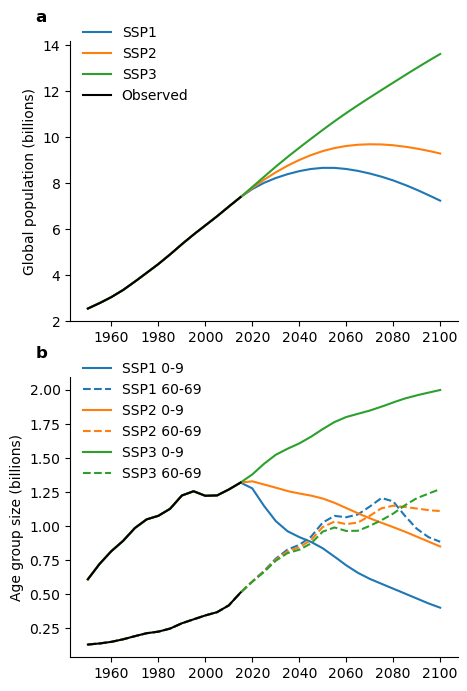

In [ ]:
# settings
xpos=-.09
ypos=1.04


fig, axes = plt.subplots(2,1, figsize=(5,8))

ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)

(da_cohort_sizes_ssp1/1e6).sum(dim='ages').plot(ax=ax, label = 'SSP1')
(da_cohort_sizes/1e6).sum(dim='ages').plot(ax=ax, label = 'SSP2')
(da_cohort_sizes_ssp3/1e6).sum(dim='ages').plot(ax=ax, label = 'SSP3')
(da_cohort_sizes_ssp3/1e6).sum(dim='ages').sel(time=slice(1950,2015)).plot(ax=ax, label = 'Observed', c='k')


ax.legend(frameon=False,bbox_to_anchor=(0, 1.1),loc='upper left')
ax.set_title('')
ax.set_ylabel('Global population (billions)')
ax.set_xlabel('')


ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)

(da_cohort_sizes_ssp1/1e6).sel(ages=slice(0,9)).sum(dim='ages').plot(ax=ax, label = 'SSP1 0-9')
(da_cohort_sizes_ssp1/1e6).sel(ages=slice(60,69)).sum(dim='ages').plot(ax=ax, label = 'SSP1 60-69',c='C0',ls='--')

(da_cohort_sizes/1e6).sel(ages=slice(0,9)).sum(dim='ages').plot(ax=ax, label = 'SSP2 0-9')
(da_cohort_sizes/1e6).sel(ages=slice(60,69)).sum(dim='ages').plot(ax=ax, label = 'SSP2 60-69',c='C1',ls='--')

(da_cohort_sizes_ssp3/1e6).sel(ages=slice(0,9)).sum(dim='ages').plot(ax=ax, label = 'SSP3 0-9')
(da_cohort_sizes_ssp3/1e6).sel(ages=slice(60,69)).sum(dim='ages').plot(ax=ax, label = 'SSP3 60-69',c='C2',ls='--')

(da_cohort_sizes_ssp3/1e6).sel(ages=slice(0,9)).sum(dim='ages').sel(time=slice(1950,2015)).plot(ax=ax, c='k')
(da_cohort_sizes_ssp3/1e6).sel(ages=slice(60,69)).sum(dim='ages').sel(time=slice(1950,2015)).plot(ax=ax, c='k')


ax.legend(frameon=False, bbox_to_anchor=(0, 1.1),loc='upper left')
ax.set_title('')
ax.set_ylabel('Age group size (billions)')
ax.set_xlabel('')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

#plt.savefig(os.path.join(figdir,'figSI_globalpop_agegroups_ssp123_v2.png'),dpi=300,transparent=True)

## 1. If demographics were constant at present-day levels


In [29]:
x_hot_days = [0, 1, 20, 50, 100, 150]

da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=1.5) 

da_n_people_ndays_models_15_fd, da_prop_people_ndays_models_15_fd = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2023, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_15_fd = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2023, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) 

da_n_people_ndays_models_2_fd, da_prop_people_ndays_models_2_fd = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2023, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_2_fd = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2023, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


## 2. SSP3-45 instead of SSP2-45

In [ ]:

da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=1.5) 

da_n_people_ndays_models_15_ssp3, da_prop_people_ndays_models_15_ssp3 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2033_ssp3, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_15_ssp3 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2033_ssp3, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )


da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) 

da_n_people_ndays_models_2_ssp3, da_prop_people_ndays_models_2_ssp3 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2062_ssp3,
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)


da_nAHD_percapita_peopledays_2_ssp3 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2062_ssp3, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

## 2 deg with RCP6.0 instead of 4.5

In [ ]:
da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) 

da_n_people_ndays_models_2_rcp6, da_prop_people_ndays_models_2_rcp6 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2056, 
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_2_rcp6 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2056, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )



da_nAHD = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=2) 

da_n_people_ndays_models_2_rcp6_ssp3, da_prop_people_ndays_models_2_rcp6_ssp3 = calc_number_proportion_people_atleastxdays_10yr(gs_population_global_2051_ssp3,
                                                                                          GCMs, 
                                                                                          da_nAHD,  
                                                                                          x_hot_days = x_hot_days)

da_nAHD_percapita_peopledays_2_rcp6_ssp3 = calc_percapita_hotdays_peopledays_1yr(gs_population_global_2051_ssp3, 
                                                                           GCMs, 
                                                                           da_nAHD,
                                                                           ages_values=range(0,100),
                                                                           grouped = True,
                                                                           size_win = 10,
                                                                         mask_where_decr=False
                                                                           )

# Summary table

In [ ]:
def add_population_data(df, col_name, gs_population_global, da_n_people_ndays, da_prop_people_ndays, da_percap):

    # total npeople
    ntot=gs_population_global.sel(ages=slice(0,9)).sum()
    ntot_60=gs_population_global.sel(ages=slice(60,69)).sum()

    #0-9
    n_atleastx=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:] / 1e6
    prop_atleastx=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:]
    percap = da_percap.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1]

    #60-60
    n_atleastx_60=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1:] / 1e6
    prop_atleastx_60=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1:]
    percap_60 = da_percap.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1]

    # ratios
    ratio_percap = (da_percap.sel(age_ranges=0,features='per_capita_days') / da_percap.sel(age_ranges=60,features='per_capita_days')).median(dim='model').values


    labels = ['1+', '20+','50+','100+', '150+']
    
    # Add population totals
    df.loc["Pop 0-9", col_name] = np.round(ntot.item() / 1e9, 1)

    # Add population and proportion data
    for i in range(len(n_atleastx)):
        df.loc[f"0-9 {labels[i]}", col_name] = f"{prop_atleastx.iloc[i]:.0%} ({n_atleastx.iloc[i].round(-1):.0f})"
    
    df.loc["Pop 60-69", col_name] = np.round(ntot_60.item() / 1e9, 1)

    for i in range(len(n_atleastx)):
        df.loc[f"60-69 {labels[i]}", col_name] = f"{prop_atleastx_60.iloc[i]:.0%} ({n_atleastx_60.iloc[i].round(-1):.0f})"

    # Add ratios
    for i in range(len(n_atleastx)):
        ratio_n = (da_n_people_ndays.sel(age_ranges=0) / da_n_people_ndays.sel(age_ranges=60)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio n {labels[i]}", col_name] = f"{ratio_n:.1f}"

    for i in range(len(n_atleastx)):
        ratio_prop = (da_prop_people_ndays.sel(age_ranges=0) / da_prop_people_ndays.sel(age_ranges=60)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio prop {labels[i]}", col_name] = f"{ratio_prop:.1f}"

    df.loc["percap 0-9",col_name] = int(percap.round(0))
    df.loc["percap 60-69",col_name] = int(percap_60.round(0))
    df.loc['ratio percap',col_name]=ratio_percap.round(1)
    
    return df

In [ ]:
df_out = pd.DataFrame()


# baseline scenarios, demographics from SSP2-RCP45 year

df_out = add_population_data(df_out, "PD + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models, da_prop_people_ndays_models, da_nAHD_percapita_peopledays)

df_out = add_population_data(df_out, "1.5 + SSP2_2034", gs_population_global_2034, da_n_people_ndays_models_15, da_prop_people_ndays_models_15, da_nAHD_percapita_peopledays_15)

df_out = add_population_data(df_out, "2 + SSP2_2062", gs_population_global_2062, da_n_people_ndays_models_2, da_prop_people_ndays_models_2, da_nAHD_percapita_peopledays_2)


# 1.5 and 2 deg scenario with SSP3-45 instead of SSP2-45

df_out = add_population_data(df_out, "1.5 + SSP3_2033", gs_population_global_2033_ssp3, da_n_people_ndays_models_15_ssp3, da_prop_people_ndays_models_15_ssp3, da_nAHD_percapita_peopledays_15_ssp3)

df_out = add_population_data(df_out, "2 + SSP3_2062", gs_population_global_2062_ssp3, da_n_people_ndays_models_2_ssp3, da_prop_people_ndays_models_2_ssp3, da_nAHD_percapita_peopledays_2_ssp3)


# 1.5 and 2 deg with fixed demographics 

df_out = add_population_data(df_out, "1.5 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_15_fd, da_prop_people_ndays_models_15_fd, da_nAHD_percapita_peopledays_15_fd)

df_out = add_population_data(df_out, "2 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_2_fd, da_prop_people_ndays_models_2_fd, da_nAHD_percapita_peopledays_2_fd)


# 2 deg with RCP6 (ssp2 and ssp3) instead of RCP45

df_out = add_population_data(df_out, "2 + SSP2_2056", gs_population_global_2056, da_n_people_ndays_models_2_rcp6, da_prop_people_ndays_models_2_rcp6, da_nAHD_percapita_peopledays_2_rcp6)

df_out = add_population_data(df_out, "2 + SSP3_2051", gs_population_global_2051_ssp3, da_n_people_ndays_models_2_rcp6_ssp3, da_prop_people_ndays_models_2_rcp6_ssp3, da_nAHD_percapita_peopledays_2_rcp6_ssp3)

df_out

,PD + SSP2_2023,1.5 + SSP2_2034,2 + SSP2_2062,1.5 + SSP3_2033,2 + SSP3_2062,1.5 + SSP2_2023,2 + SSP2_2023,2 + SSP2_2056,2 + SSP3_2051
Pop 0-9,1.3,1.3,1.1,1.5,1.8,1.3,1.3,1.2,1.7
0-9 1+,74% (970),75% (940),78% (870),75% (1160),78% (1410),75% (990),79% (1040),78% (910),78% (1350)
0-9 20+,52% (690),58% (730),64% (720),58% (900),65% (1170),57% (750),65% (850),65% (750),65% (1120)
0-9 50+,29% (380),34% (430),45% (500),34% (530),46% (820),33% (430),43% (560),45% (520),45% (780)
0-9 100+,11% (140),13% (170),23% (260),13% (210),24% (430),13% (170),22% (280),23% (270),23% (400)
0-9 150+,3% (40),4% (50),10% (120),4% (60),10% (190),4% (60),10% (140),10% (120),10% (180)
Pop 60-69,0.6,0.8,1.0,0.8,1.0,0.6,0.6,1.0,1.0
60-69 1+,70% (450),75% (600),80% (820),74% (580),80% (770),73% (460),77% (490),80% (820),80% (770)
60-69 20+,38% (240),46% (370),63% (650),46% (360),64% (610),43% (280),56% (360),62% (640),61% (590)
60-69 50+,18% (110),23% (190),39% (390),23% (180),39% (380),22% (140),30% (190),36% (370),35% (340)


In [ ]:
#df_out.to_csv(os.path.join(outdirs,'output_SI_tables/fig3_sensitivity_table.csv'))

In [ ]:
# pyoung pd, 1.5, 2

d1 = da_prop_people_ndays_models.sel(age_ranges=0, features='prop_atleast_150').values
d2 =  da_prop_people_ndays_models_15.sel(age_ranges=0, features='prop_atleast_150').values
d3 = da_prop_people_ndays_models_2.sel(age_ranges=0, features='prop_atleast_150').values

data = np.vstack([d1, d2, d3])

d = np.array([np.median(data,axis=1), np.min(data, axis=1), np.max(data,axis=1)]).T
df_pyoung = pd.DataFrame(d, index=["2023", "1.5", "2"], columns=["median", "min", "max"]).astype(float)

df_pyoung.round(2)

,median,min,max
2023,0.03,0.01,0.04
1.5,0.04,0.03,0.07
2,0.10,0.06,0.14


In [ ]:
gs_population_global_2023.sel(ages=slice(60,69)).sum().values

array(6.38126118e+08)

In [ ]:
gs_population_global_2023.sum().values

array(8.00867559e+09)

In [ ]:
nyoung = np.array([gs_population_global_2023.sel(ages=slice(0,9)).sum().values, 
                   gs_population_global_2034.sel(ages=slice(0,9)).sum().values,
                   gs_population_global_2062.sel(ages=slice(0,9)).sum().values])
nyoung.round(-7)

# total number of people aged 0-9 in each period in SSP2

array([1.31e+09, 1.26e+09, 1.11e+09])

In [ ]:
df_nyoung = df_pyoung.multiply(nyoung, axis=0).astype(float)
df_nyoung.round(-5) / 1e6 # units: millions 

,median,min,max
2023,40.4,19.1,56.1
1.5,51.0,34.5,82.6
2,115.4,63.6,161.5


In [ ]:
# pold pd, 1.5, 2

d1 = da_prop_people_ndays_models.sel(age_ranges=60, features='prop_atleast_150').values
d2 =  da_prop_people_ndays_models_15.sel(age_ranges=60, features='prop_atleast_150').values
d3 = da_prop_people_ndays_models_2.sel(age_ranges=60, features='prop_atleast_150').values

data = np.vstack([d1, d2, d3])

d = np.array([np.median(data,axis=1), np.min(data, axis=1), np.max(data,axis=1)]).T
df_pold = pd.DataFrame(d, index=["2023", "1.5", "2"], columns=["median", "min", "max"]).astype(float)

df_pold.round(2)

,median,min,max
2023,0.03,0.01,0.03
1.5,0.04,0.03,0.05
2,0.09,0.07,0.11


In [ ]:
nold = np.array([gs_population_global_2023.sel(ages=slice(60,69)).sum().values, 
                   gs_population_global_2034.sel(ages=slice(60,69)).sum().values,
                   gs_population_global_2062.sel(ages=slice(60,69)).sum().values])
nold.round(-7)

array([6.40e+08, 8.00e+08, 1.02e+09])

In [ ]:
df_nold = df_pold.multiply(nold, axis=0).astype(float)
df_nold.round(-5) / 1e6 # units: millions 

,median,min,max
2023,16.7,8.3,20.1
1.5,30.6,21.3,40.5
2,93.8,66.1,116.6


In [ ]:
# polder pd, 1.5, 2 50 or more, 80-89 yo

d1 = da_prop_people_ndays_models.sel(age_ranges=80, features='prop_atleast_50').values
d2 =  da_prop_people_ndays_models_15.sel(age_ranges=80, features='prop_atleast_50').values
d3 = da_prop_people_ndays_models_2.sel(age_ranges=80, features='prop_atleast_50').values

data = np.vstack([d1, d2, d3])

d = np.array([np.median(data,axis=1), np.min(data, axis=1), np.max(data,axis=1)]).T
df_polder = pd.DataFrame(d, index=["2023", "1.5", "2"], columns=["median", "min", "max"]).astype(float)

df_polder.round(2)

,median,min,max
2023,0.12,0.09,0.18
1.5,0.16,0.10,0.20
2,0.29,0.22,0.34


# Extra figure for SF

Do it not rounded for plot

In [ ]:
def add_population_data(df, col_name, gs_population_global, da_n_people_ndays, da_prop_people_ndays, da_percap):

    # total npeople
    ntot=gs_population_global.sel(ages=slice(0,9)).sum()
    ntot_60=gs_population_global.sel(ages=slice(60,69)).sum()

    #0-9
    n_atleastx=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:] / 1e6
    prop_atleastx=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:]
    percap = da_percap.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1]

    #60-60
    n_atleastx_60=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1:] / 1e6
    prop_atleastx_60=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1:]
    percap_60 = da_percap.astype(float).median(dim='model').sel(age_ranges=60).to_pandas()[1]

    # ratios
    ratio_percap = (da_percap.sel(age_ranges=0,features='per_capita_days') / da_percap.sel(age_ranges=60,features='per_capita_days')).median(dim='model').values


    labels = ['1+', '20+','50+','100+', '150+']
    
    # Add population totals
    df.loc["Pop 0-9", col_name] = np.round(ntot.item() / 1e9, 3)

    # Add population and proportion data
    for i in range(len(n_atleastx)):
        df.loc[f"0-9 {labels[i]}", col_name] = f"{prop_atleastx.iloc[i]:.3%} ({n_atleastx.iloc[i]})"
    
    df.loc["Pop 60-69", col_name] = np.round(ntot_60.item() / 1e9, 1)

    for i in range(len(n_atleastx)):
        df.loc[f"60-69 {labels[i]}", col_name] = f"{prop_atleastx_60.iloc[i]:.3%} ({n_atleastx_60.iloc[i]})"

    # Add ratios
    for i in range(len(n_atleastx)):
        ratio_n = (da_n_people_ndays.sel(age_ranges=0) / da_n_people_ndays.sel(age_ranges=60)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio n {labels[i]}", col_name] = f"{ratio_n}"

    for i in range(len(n_atleastx)):
        ratio_prop = (da_prop_people_ndays.sel(age_ranges=0) / da_prop_people_ndays.sel(age_ranges=60)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio prop {labels[i]}", col_name] = f"{ratio_prop}"

    df.loc["percap 0-9",col_name] = percap
    df.loc["percap 60-69",col_name] = percap_60
    df.loc['ratio percap',col_name]=ratio_percap
    
    return df

In [ ]:
df_out = pd.DataFrame()


# baseline scenarios, demographics from SSP2-RCP45 year

df_out = add_population_data(df_out, "PD + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models, da_prop_people_ndays_models, da_nAHD_percapita_peopledays)

df_out = add_population_data(df_out, "1.5 + SSP2_2034", gs_population_global_2034, da_n_people_ndays_models_15, da_prop_people_ndays_models_15, da_nAHD_percapita_peopledays_15)

df_out = add_population_data(df_out, "2 + SSP2_2062", gs_population_global_2062, da_n_people_ndays_models_2, da_prop_people_ndays_models_2, da_nAHD_percapita_peopledays_2)


# 1.5 and 2 deg scenario with SSP3-45 instead of SSP2-45

df_out = add_population_data(df_out, "1.5 + SSP3_2033", gs_population_global_2033_ssp3, da_n_people_ndays_models_15_ssp3, da_prop_people_ndays_models_15_ssp3, da_nAHD_percapita_peopledays_15_ssp3)

df_out = add_population_data(df_out, "2 + SSP3_2062", gs_population_global_2062_ssp3, da_n_people_ndays_models_2_ssp3, da_prop_people_ndays_models_2_ssp3, da_nAHD_percapita_peopledays_2_ssp3)


# 1.5 and 2 deg with fixed demographics 

df_out = add_population_data(df_out, "1.5 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_15_fd, da_prop_people_ndays_models_15_fd, da_nAHD_percapita_peopledays_15_fd)

df_out = add_population_data(df_out, "2 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_2_fd, da_prop_people_ndays_models_2_fd, da_nAHD_percapita_peopledays_2_fd)


# 2 deg with RCP6 (ssp2 and ssp3) instead of RCP45

df_out = add_population_data(df_out, "2 + SSP2_2056", gs_population_global_2056, da_n_people_ndays_models_2_rcp6, da_prop_people_ndays_models_2_rcp6, da_nAHD_percapita_peopledays_2_rcp6)

df_out = add_population_data(df_out, "2 + SSP3_2051", gs_population_global_2051_ssp3, da_n_people_ndays_models_2_rcp6_ssp3, da_prop_people_ndays_models_2_rcp6_ssp3, da_nAHD_percapita_peopledays_2_rcp6_ssp3)

df_out.round(1)

,PD + SSP2_2023,1.5 + SSP2_2034,2 + SSP2_2062,1.5 + SSP3_2033,2 + SSP3_2062,1.5 + SSP2_2023,2 + SSP2_2023,2 + SSP2_2056,2 + SSP3_2051
Pop 0-9,1.315,1.259,1.115,1.548,1.807,1.315,1.315,1.161,1.719
0-9 1+,74.056% (973.6299970699732),75.030% (944.8675454811463),78.378% (873.591038151238),75.018% (1161.1159754408227),78.186% (1412.7982539057396),75.273% (989.632593378479),79.336% (1043.0497829507692),78.416% (910.2656620205007),78.383% (1347.7857178651439)
0-9 20+,52.272% (687.2291176073396),57.919% (729.3867021467316),64.477% (718.6475025690875),57.880% (895.8591686119158),64.856% (1171.9284665182743),56.732% (745.8651533702338),64.926% (853.6046945033833),64.509% (748.8379453122902),64.935% (1116.5504960690362)
0-9 50+,28.712% (377.4832352784936),34.154% (430.10976831427513),45.097% (502.6404978685242),34.163% (528.7626629310323),45.604% (824.0392809079366),32.735% (430.37094059418473),42.932% (564.4447842566822),44.827% (520.3594355022611),45.184% (776.9303096058512)
0-9 100+,10.669% (140.26230106031892),13.466% (169.5797458807649),23.471% (261.6026976617979),13.456% (208.266976371987),23.586% (426.18281167098115),13.088% (172.07016551012566),21.505% (282.7358579984939),23.284% (270.2891286298057),23.363% (401.72253337277544)
0-9 150+,3.071% (40.37572162683201),4.046% (50.95567944350897),10.351% (115.36721686747936),4.057% (62.79015530416347),10.328% (186.62350336322294),4.214% (55.39871235416211),10.398% (136.70148962932026),10.331% (119.92685304933309),10.371% (178.32423042714274)
Pop 60-69,0.6,0.8,1.0,0.8,1.0,0.6,0.6,1.0,1.0
60-69 1+,70.155% (447.6768588976711),74.698% (597.6757495225031),80.250% (816.4751870828337),74.464% (578.7860645511133),80.392% (774.5196308497634),72.520% (462.7706026898844),77.126% (492.16288153690834),79.909% (820.9465537340953),79.556% (766.7756550686858)
60-69 20+,37.669% (240.37548285280994),45.955% (367.6970007895154),63.456% (645.6049128390854),45.749% (355.59606956712116),63.713% (613.8267640333297),43.456% (277.3042388984972),55.944% (356.9923499811698),62.256% (639.5890408724322),61.419% (591.9675322230123)
60-69 50+,17.741% (113.2105411978756),23.250% (186.0245748729297),38.733% (394.0688687859143),23.075% (179.35921863812584),38.964% (375.3883055409909),21.723% (138.62080018517045),29.772% (189.9842795785616),36.340% (373.3401855422709),35.202% (339.282496958196)


## MF per capita days

In [ ]:
df_out.loc[['ratio percap']]

,PD + SSP2_2023,1.5 + SSP2_2034,2 + SSP2_2062,1.5 + SSP3_2033,2 + SSP3_2062,1.5 + SSP2_2023,2 + SSP2_2023,2 + SSP2_2056,2 + SSP3_2051
ratio percap,1.373215964070568,1.298195459827709,1.1107994738694091,1.3076680324629746,1.1130315899800194,1.3551502079223117,1.354537359029822,1.169336904164819,1.2101953593173937


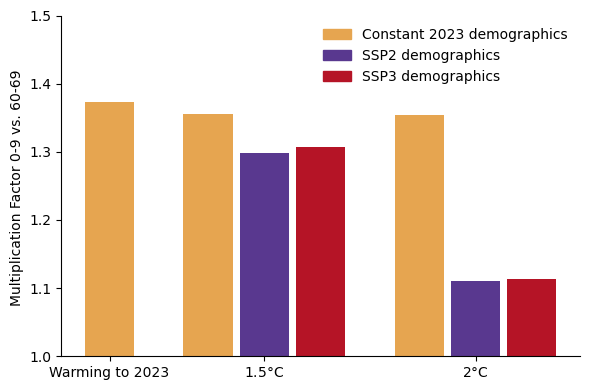

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

row = df_out.loc['ratio percap']

# Group column labels
g1 = [row.index[0]]
g2 = [row.index[5], row.index[1], row.index[3]]
g3 = [col for col in row.index if col not in g1 + g2]
g3 = [g3[i] for i in [2, 0, 1]]  # get rid of RCP6, reorder

groups = [g1, g2, g3]

# Parameters
bar_width = 0.7           # slightly less than 0.8 to add space between bars
intra_gap = 0.1           # spacing between bars within a group
group_spacing = .7       # spacing between groups

# Compute x positions
x = []
x_labels = []
x_pos = 0
for g in groups:
    group_x = np.arange(len(g)) * (bar_width + intra_gap) + x_pos
    x.append(group_x)
    x_labels.extend(g)
    x_pos = group_x[-1] + group_spacing + bar_width  # space after last bar

x = np.concatenate(x)
y = row.reindex(x_labels).values

group_labels = ['Constant 2023 demographics', 'SSP2 demographics', 'SSP3 demographics']
colors =  ['#e6a550',  '#59388f', '#b51426', ]
bar_colors = [colors[0], colors[0], colors[1], colors[2], colors[0], colors[1], colors[2] ]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, y, width=bar_width, align='center', color=bar_colors)

# Axis formatting
# ax.set_xticks(x)
# ax.set_xticklabels(x_labels, rotation=45, ha='right')

# Axis formatting

ax.set_xticks(x[[0,2,5]])
x_labels=['Warming to 2023', '1.5$\degree$C', '2$\degree$C']
ax.set_xticklabels(x_labels, rotation=0, ha='center')



ax.set_ylabel('Multiplication Factor 0-9 vs. 60-69 ')

# Custom legend
legend_handles = [Patch(color=c, label=lbl) for c, lbl in zip(colors, group_labels)]
ax.legend(handles=legend_handles, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(1,1.5)
plt.tight_layout()
#plt.show()

# number of days exposed per capita

#plt.savefig(os.path.join(figdir,'figSI_MF_dayspercap_futuredemographics.png'),dpi=300,transparent=True)

## MF number of people exposed to 50+ days

In [ ]:
df_out.loc['ratio n 50+'].astype(float)

PD + SSP2_2023     3.334206
1.5 + SSP2_2034    2.374792
2 + SSP2_2062      1.276559
1.5 + SSP3_2033    3.025389
2 + SSP3_2062      2.198858
1.5 + SSP2_2023    3.208234
2 + SSP2_2023      3.000202
2 + SSP2_2056      1.400027
2 + SSP3_2051      2.303976
Name: ratio n 50+, dtype: float64

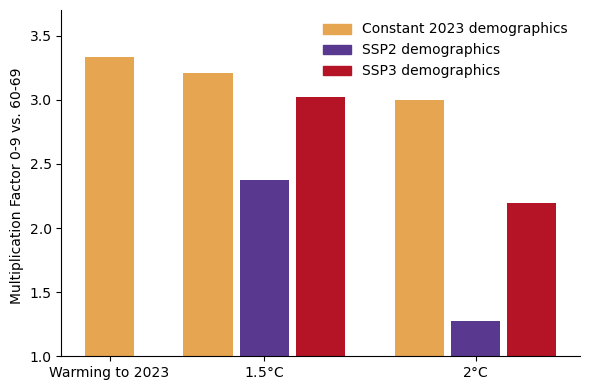

In [ ]:

row = df_out.loc['ratio n 50+'].astype(float)

# Group column labels
g1 = [row.index[0]]
g2 = [row.index[5], row.index[1], row.index[3]]
g3 = [col for col in row.index if col not in g1 + g2]
g3 = [g3[i] for i in [2, 0, 1]]  # get rid of RCP6, reorder

groups = [g1, g2, g3]

# Parameters
bar_width = 0.7           # slightly less than 0.8 to add space between bars
intra_gap = 0.1           # spacing between bars within a group
group_spacing = .7       # spacing between groups

# Compute x positions
x = []
x_labels = []
x_pos = 0
for g in groups:
    group_x = np.arange(len(g)) * (bar_width + intra_gap) + x_pos
    x.append(group_x)
    x_labels.extend(g)
    x_pos = group_x[-1] + group_spacing + bar_width  # space after last bar

x = np.concatenate(x)
y = row.reindex(x_labels).values

group_labels = ['Constant 2023 demographics', 'SSP2 demographics', 'SSP3 demographics']
colors =  ['#e6a550',  '#59388f', '#b51426', ]
bar_colors = [colors[0], colors[0], colors[1], colors[2], colors[0], colors[1], colors[2] ]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, y, width=bar_width, align='center', color=bar_colors)

#Axis formatting
# ax.set_xticks(x)
# ax.set_xticklabels(x_labels, rotation=45, ha='right')

# Axis formatting

ax.set_xticks(x[[0,2,5]])
x_labels=['Warming to 2023', '1.5$\degree$C', '2$\degree$C']
ax.set_xticklabels(x_labels, rotation=0, ha='center')



ax.set_ylabel('Multiplication Factor 0-9 vs. 60-69 ')

# Custom legend
legend_handles = [Patch(color=c, label=lbl) for c, lbl in zip(colors, group_labels)]
ax.legend(handles=legend_handles, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(1,3.7)
plt.tight_layout()
plt.show()

In [ ]:
 # Did I interpret this??? 

## Test 40-49

Do it not rounded for plot

In [ ]:
def add_population_data(df, col_name, gs_population_global, da_n_people_ndays, da_prop_people_ndays, da_percap):

    age_old=40

    # total npeople
    ntot=gs_population_global.sel(ages=slice(0,9)).sum()
    ntot_60=gs_population_global.sel(ages=slice(age_old,age_old+9)).sum()

    #0-9
    n_atleastx=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:] / 1e6
    prop_atleastx=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1:]
    percap = da_percap.astype(float).median(dim='model').sel(age_ranges=0).to_pandas()[1]

    #60-60
    n_atleastx_60=da_n_people_ndays.astype(float).median(dim='model').sel(age_ranges=age_old).to_pandas()[1:] / 1e6
    prop_atleastx_60=da_prop_people_ndays.astype(float).median(dim='model').sel(age_ranges=age_old).to_pandas()[1:]
    percap_60 = da_percap.astype(float).median(dim='model').sel(age_ranges=age_old).to_pandas()[1]

    # ratios
    ratio_percap = (da_percap.sel(age_ranges=0,features='per_capita_days') / da_percap.sel(age_ranges=age_old,features='per_capita_days')).median(dim='model').values


    labels = ['1+','50+','100+', '150+']
    
    # Add population totals
    df.loc["Pop 0-9", col_name] = np.round(ntot.item() / 1e9, 3)

    # Add population and proportion data
    for i in range(len(n_atleastx)):
        df.loc[f"0-9 {labels[i]}", col_name] = f"{prop_atleastx.iloc[i]:.3%} ({n_atleastx.iloc[i]})"
    
    df.loc[f"Pop {age_old}-{age_old+9}", col_name] = np.round(ntot_60.item() / 1e9, 3)

    for i in range(len(n_atleastx)):
        df.loc[f"{age_old}-{age_old+9} {labels[i]}", col_name] = f"{prop_atleastx_60.iloc[i]:.3%} ({n_atleastx_60.iloc[i]})"

    # Add ratios
    for i in range(len(n_atleastx)):
        ratio_n = (da_n_people_ndays.sel(age_ranges=0) / da_n_people_ndays.sel(age_ranges=age_old)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio n {labels[i]}", col_name] = f"{ratio_n}"

    for i in range(len(n_atleastx)):
        ratio_prop = (da_prop_people_ndays.sel(age_ranges=0) / da_prop_people_ndays.sel(age_ranges=age_old)).isel(features=slice(1, None)).astype(float).median(dim='model').values[i]
        df.loc[f"ratio prop {labels[i]}", col_name] = f"{ratio_prop}"

    df.loc["percap 0-9",col_name] = percap
    df.loc[f"percap {age_old}-{age_old+9}",col_name] = percap_60
    df.loc['ratio percap',col_name]=ratio_percap
    
    return df

In [ ]:
df_out = pd.DataFrame()


# baseline scenarios, demographics from SSP2-RCP45 year

df_out = add_population_data(df_out, "PD + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models, da_prop_people_ndays_models, da_nAHD_percapita_peopledays)

df_out = add_population_data(df_out, "1.5 + SSP2_2034", gs_population_global_2034, da_n_people_ndays_models_15, da_prop_people_ndays_models_15, da_nAHD_percapita_peopledays_15)

df_out = add_population_data(df_out, "2 + SSP2_2062", gs_population_global_2062, da_n_people_ndays_models_2, da_prop_people_ndays_models_2, da_nAHD_percapita_peopledays_2)


# 1.5 and 2 deg scenario with SSP3-45 instead of SSP2-45

df_out = add_population_data(df_out, "1.5 + SSP3_2033", gs_population_global_2033_ssp3, da_n_people_ndays_models_15_ssp3, da_prop_people_ndays_models_15_ssp3, da_nAHD_percapita_peopledays_15_ssp3)

df_out = add_population_data(df_out, "2 + SSP3_2062", gs_population_global_2062_ssp3, da_n_people_ndays_models_2_ssp3, da_prop_people_ndays_models_2_ssp3, da_nAHD_percapita_peopledays_2_ssp3)


# 1.5 and 2 deg with fixed demographics 

df_out = add_population_data(df_out, "1.5 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_15_fd, da_prop_people_ndays_models_15_fd, da_nAHD_percapita_peopledays_15_fd)

df_out = add_population_data(df_out, "2 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_2_fd, da_prop_people_ndays_models_2_fd, da_nAHD_percapita_peopledays_2_fd)


# 2 deg with RCP6 (ssp2 and ssp3) instead of RCP45

df_out = add_population_data(df_out, "2 + SSP2_2056", gs_population_global_2056, da_n_people_ndays_models_2_rcp6, da_prop_people_ndays_models_2_rcp6, da_nAHD_percapita_peopledays_2_rcp6)

df_out = add_population_data(df_out, "2 + SSP3_2051", gs_population_global_2051_ssp3, da_n_people_ndays_models_2_rcp6_ssp3, da_prop_people_ndays_models_2_rcp6_ssp3, da_nAHD_percapita_peopledays_2_rcp6_ssp3)

df_out

,PD + SSP2_2023,1.5 + SSP2_2034,2 + SSP2_2062,1.5 + SSP3_2033,2 + SSP3_2062,1.5 + SSP2_2023,2 + SSP2_2023,2 + SSP2_2056,2 + SSP3_2051
Pop 0-9,1.315,1.259,1.115,1.548,1.807,1.315,1.315,1.161,1.719
0-9 1+,74.056% (973.6299970699732),75.030% (944.8675454811463),78.378% (873.591038151238),75.018% (1161.1159754408227),78.186% (1412.7982539057396),75.273% (989.632593378479),79.336% (1043.0497829507692),78.416% (910.2656620205007),78.383% (1347.7857178651439)
0-9 20+,52.272% (687.2291176073396),57.919% (729.3867021467316),64.477% (718.6475025690875),57.880% (895.8591686119158),64.856% (1171.9284665182743),56.732% (745.8651533702338),64.926% (853.6046945033833),64.509% (748.8379453122902),64.935% (1116.5504960690362)
0-9 50+,28.712% (377.4832352784936),34.154% (430.10976831427513),45.097% (502.6404978685242),34.163% (528.7626629310323),45.604% (824.0392809079366),32.735% (430.37094059418473),42.932% (564.4447842566822),44.827% (520.3594355022611),45.184% (776.9303096058512)
0-9 100+,10.669% (140.26230106031892),13.466% (169.5797458807649),23.471% (261.6026976617979),13.456% (208.266976371987),23.586% (426.18281167098115),13.088% (172.07016551012566),21.505% (282.7358579984939),23.284% (270.2891286298057),23.363% (401.72253337277544)
0-9 150+,3.071% (40.37572162683201),4.046% (50.95567944350897),10.351% (115.36721686747936),4.057% (62.79015530416347),10.328% (186.62350336322294),4.214% (55.39871235416211),10.398% (136.70148962932026),10.331% (119.92685304933309),10.371% (178.32423042714274)
Pop 60-69,0.6,0.8,1.0,0.8,1.0,0.6,0.6,1.0,1.0
60-69 1+,70.155% (447.6768588976711),74.698% (597.6757495225031),80.250% (816.4751870828337),74.464% (578.7860645511133),80.392% (774.5196308497634),72.520% (462.7706026898844),77.126% (492.16288153690834),79.909% (820.9465537340953),79.556% (766.7756550686858)
60-69 20+,37.669% (240.37548285280994),45.955% (367.6970007895154),63.456% (645.6049128390854),45.749% (355.59606956712116),63.713% (613.8267640333297),43.456% (277.3042388984972),55.944% (356.9923499811698),62.256% (639.5890408724322),61.419% (591.9675322230123)
60-69 50+,17.741% (113.2105411978756),23.250% (186.0245748729297),38.733% (394.0688687859143),23.075% (179.35921863812584),38.964% (375.3883055409909),21.723% (138.62080018517045),29.772% (189.9842795785616),36.340% (373.3401855422709),35.202% (339.282496958196)


# Reviews: decompose better saturation effects vs. ageing population


Add analysis separating the role of demographic change vs. saturation of heat exposure leading to decreasing I-E in time in future projections

1. % age group exposed today, 1.5, 2 with different demographics (SSP2 vs. constant present-day demographics)
2. to 20+ days and to 1+ days (as in paper, saturation)


In [ ]:

# baseline scenarios, demographics from SSP2-RCP45 year

# "PD + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models, da_prop_people_ndays_models, da_nAHD_percapita_peopledays)
#"1.5 + SSP2_2034", gs_population_global_2034, da_n_people_ndays_models_15, da_prop_people_ndays_models_15, da_nAHD_percapita_peopledays_15)
#"2 + SSP2_2062", gs_population_global_2062, da_n_people_ndays_models_2, da_prop_people_ndays_models_2, da_nAHD_percapita_peopledays_2)


# 1.5 and 2 deg scenario with SSP3-45 instead of SSP2-45

#"1.5 + SSP3_2033", gs_population_global_2033_ssp3, da_n_people_ndays_models_15_ssp3, da_prop_people_ndays_models_15_ssp3, da_nAHD_percapita_peopledays_15_ssp3)
#"2 + SSP3_2062", gs_population_global_2062_ssp3, da_n_people_ndays_models_2_ssp3, da_prop_people_ndays_models_2_ssp3, da_nAHD_percapita_peopledays_2_ssp3)


# 1.5 and 2 deg with fixed demographics 

#"1.5 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_15_fd, da_prop_people_ndays_models_15_fd, da_nAHD_percapita_peopledays_15_fd)
#"2 + SSP2_2023", gs_population_global_2023, da_n_people_ndays_models_2_fd, da_prop_people_ndays_models_2_fd, da_nAHD_percapita_peopledays_2_fd)


# 2 deg with RCP6 (ssp2 and ssp3) instead of RCP45

#"2 + SSP2_2056", gs_population_global_2056, da_n_people_ndays_models_2_rcp6, da_prop_people_ndays_models_2_rcp6, da_nAHD_percapita_peopledays_2_rcp6)
#"2 + SSP3_2051", gs_population_global_2051_ssp3, da_n_people_ndays_models_2_rcp6_ssp3, da_prop_people_ndays_models_2_rcp6_ssp3, da_nAHD_percapita_peopledays_2_rcp6_ssp3)



In [30]:

def plot_barplot_n_prop_people_atleastx_modelmedian(da, 
                                                  unit, 
                                                  ax, 
                                                  year=2022, 
                                                  proportion=False, 
                                                  x_hot_days = [1,5,10,20,50],
                                                 legend=True,
                                                 errcolor='gray',
                                                 color=None,
                                                 alpha=1,
                                                 set_xticklabel=True,
                                                 rotation=40,
                                                 ylabel=None, 
                                                 label=None,
                                                 offset=0,
                                                 width=.4,
                                                 bottom=0
                                                 ):
    # plot range 
    if unit == 1e9:
        unit_str = 'billions'
    elif unit == 1e6:
        unit_str='millions'
    else:
        unit_str = ''

    upper_error = (da.max(dim='model')-da.astype(float).median(dim='model')).values.T /unit
    lower_error = (da.astype(float).median(dim='model')-da.min(dim='model')).values.T /unit
    try:
        concatenated =np.concatenate((lower_error,upper_error), axis=1)
        reshaped = np.reshape(concatenated, (len(da.features), 2, len(da.age_ranges)))
    except:
        concatenated =np.concatenate((lower_error,upper_error))
        reshaped = np.reshape(concatenated, (2, len(da.age_ranges)))

    # get the median values as pandas Series
    y = (da.astype(float).median(dim='model')/unit).to_pandas()
    x = np.arange(len(y))  # default positions for bars

    x_shifted = x + offset
    yerr=reshaped

    # then plot using ax.bar instead of pandas plot
    ax.bar(
        x_shifted, y, 
        yerr=yerr, 
        width=width,       # narrower than 1.0 to allow spacing
        color=color,
        alpha=alpha,
        label=label,
        error_kw=dict(ecolor=errcolor, alpha=1, elinewidth=.8, capsize=1),
        bottom=bottom
    )

    # replace the x-ticks with the original positions
    ax.set_xticks(x)
    step_ages = int(da.age_ranges[1] - da.age_ranges[0] - 1)
    ax.set_xticklabels([f'{x}-{x+step_ages}' for x in da.age_ranges.values], rotation=40, ha='right')

    if ylabel is None:
        if proportion:
            ax.set_ylabel(f'Proportion of age group (%)')

        else:
            ax.set_ylabel(f'Number of people ({unit_str})')
    else:
        ax.set_ylabel(ylabel)

    ax.set_xlabel(' ')
    
    if set_xticklabel:
        step_ages = int(da.age_ranges[1] -da.age_ranges[0] - 1)
        ax.set_xticks(ticks=ax.get_xticks(), labels=[f'{x}-{x+step_ages}' for x in da.age_ranges.values],  
                      rotation=rotation, rotation_mode='anchor',ha='right') #'horizontal'
    else:
        ax.set_xticklabels('')
    
    if legend==True:
        if not label:
            ax.legend(labels = [f'at least {x}' for x in x_hot_days])

In [31]:
da_prop_people_ndays_models

<xarray.DataArray 'proportion' (model: 10, age_ranges: 10, features: 6)>
array([[[0.9996870560111445, 0.7384184234241206, 0.5564254273716224,
         0.38481580771055146, 0.12054839778646866, 0.03486261660861993],
        [0.999679441343947, 0.7435345445053763, 0.5544445732832478,
         0.3797317924211976, 0.11773723603504012, 0.03674732560850176],
        [0.9996637644866105, 0.7457411786026226, 0.5480175403854992,
         0.37131568210643284, 0.11410046246232762, 0.03821181372122272],
        [0.9995958995432221, 0.733121122344588, 0.5099666692857563,
         0.3281072868468597, 0.10123104284887781, 0.03608793363117358],
        [0.9995859707709861, 0.7246659870093407, 0.49148593571489285,
         0.31454828966512094, 0.09965288365345722, 0.03762419044945763],
        [0.999576873079366, 0.7184587849718478, 0.4543146830036949,
         0.27682963988910747, 0.0893398699145002, 0.03472568296710629],
        [0.9995206339073165, 0.6917555048540623, 0.4219812534498146,
         0.2531066700515088, 0.08060813253253288, 0.03147350697571502],
        [0.9994909874372881, 0.6622021873889411, 0.3720178676553073,
         0.21320729518653808, 0.06556771387413914, 0.025227165758023907],
        [0.9994765302298525, 0.611730927384016, 0.3149412398854956,
         0.17839086143135, 0.05350594784794211, 0.019731589029122275],
        [0.9994340824660135, 0.5806031737540003, 0.263785171940822,
         0.1483256952023251, 0.04291683851365377, 0.012988746826293968]],
...
         0.31526286685222776, 0.12632279705271604, 0.03846163850864205],
        [0.9998064315435838, 0.7556416561141508, 0.5302090410491785,
         0.3038074162271995, 0.12237674673226073, 0.03968752815611394],
        [0.9997822682485757, 0.758841182160669, 0.5215765093420307,
         0.28936925675400044, 0.11684078948123035, 0.04024187106043764],
        [0.9997332606168728, 0.7493833509163841, 0.4812667244916789,
         0.2547715440927086, 0.10237014297674399, 0.03728566579885725],
        [0.999713749386293, 0.7435345603276868, 0.4648143898415099,
         0.24484711764315628, 0.09956375403198459, 0.03835941115201891],
        [0.999687797956683, 0.7400217406897878, 0.4247747206386715,
         0.2181149345572454, 0.08811669421265535, 0.035023267119937716],
        [0.9995791031091706, 0.7161291253514641, 0.3946042484080296,
         0.19841561522476445, 0.07944663913825764, 0.03145638816542479],
        [0.9995193460804372, 0.6906467605109707, 0.3466235981750281,
         0.16736294074233374, 0.06447000242933826, 0.024921935539270537],
        [0.9994449510344208, 0.6458916326926842, 0.29444706669070586,
         0.13930024587552162, 0.0502400050409731, 0.01891877142048079],
        [0.9993181657184222, 0.6188152201871961, 0.2507022891828658,
         0.11691619276085771, 0.036759049144734074,
         0.011568394335577043]]], dtype=object)
Coordinates:
  * age_ranges  (age_ranges) int64 0 10 20 30 40 50 60 70 80 90
  * features    (features) object 'prop_atleast_0' ... 'prop_atleast_150'
  * model       (model) <U13 'CanESM5' 'CNRM-CM6-1' ... 'CNRM-ESM2-1'

## 20+ days

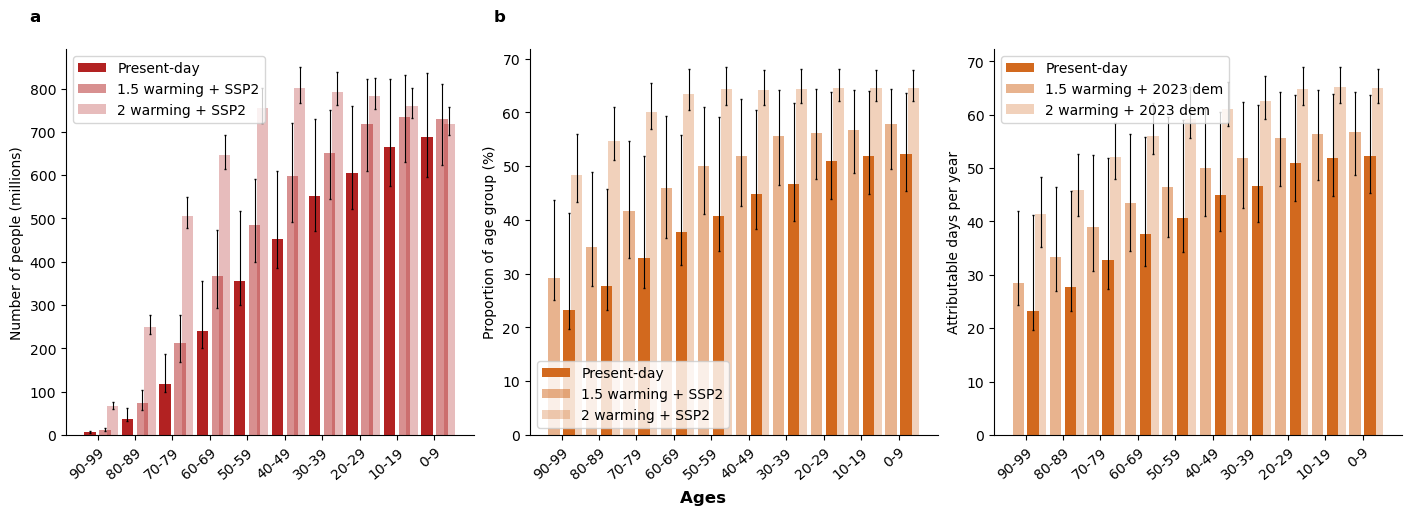

In [32]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,3,figsize=(14,5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()


ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_models.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='Present-day',
                                              offset = .2,
                                              width=.3
                                             )

plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_models_15.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='1.5 warming + SSP2',
                                              alpha=.5,
                                              offset = -.2,
                                              width=.3
                                             )

plot_barplot_n_prop_people_atleastx_modelmedian(da_n_people_ndays_models_2.sel(features='n_atleast_20'), 
                                              unit=1e6,  
                                              ax=ax, 
                                              proportion=False, 
                                              legend=True,
                                              errcolor='k',
                                              color='firebrick',
                                              set_xticklabel=True,
                                              label='2 warming + SSP2',
                                              alpha=.3,
                                              offset = -.4,
                                              width=.3
                                             )


ax.legend()


ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -.2,
                                              width=.3
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5 warming + SSP2',
                                              alpha=.5,
                                              offset = .2,
                                              width=.3
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2 warming + SSP2',
                                              alpha=.3,
                                              offset = -.4,
                                              width=.3
)

ax.legend()

ax=axes[2]

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -.2,
                                              width=.3
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fd.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5 warming + 2023 dem',
                                              alpha=.5,
                                              offset = .2,
                                              width=.3
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fd.sel(features='prop_atleast_20') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2 warming + 2023 dem',
                                              alpha=.3,
                                              offset = -.4,
                                              width=.3
)





# ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
# plot = plot_percapitadays_median_iqr(da_nAHD_percapita_peopledays_10y_obs_orig.sel(features='per_capita_days').to_pandas().iloc[:,:-1],
#                               ax=ax,
#                              set_xticklabel=False,
#                              ylabel='Attributable days per year',
#                              offset=-.2,
#                              widths=.3)

# plot2 = plot_percapitadays_median_iqr(days_percap.to_pandas().T,
#                               ax=ax,
#                              set_xticklabel=True,
#                              ylabel='Attributable days per year',
#                              offset=.2,
#                              widths=.3
#                              )
                             

# col = 'cadetblue'
# for patch in [plot['boxes'][0]]:
#     patch.set_facecolor(col)
#     patch.set_label('Original')   # <- now the label is attached to the patch


# for patch in plot2['boxes']:
#     patch.set_alpha(.5)

# col = 'cadetblue'
# for patch in [plot2['boxes'][0]]:
#     patch.set_facecolor(col)
#     patch.set_label('WorldPop')   # <- now the label is attached to the patch

# Add legend
ax.legend()


ax.set_ylabel('Attributable days per year')


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_worlpop_sensitivity.png'),bbox_inches='tight',dpi=300)


# min 20 days


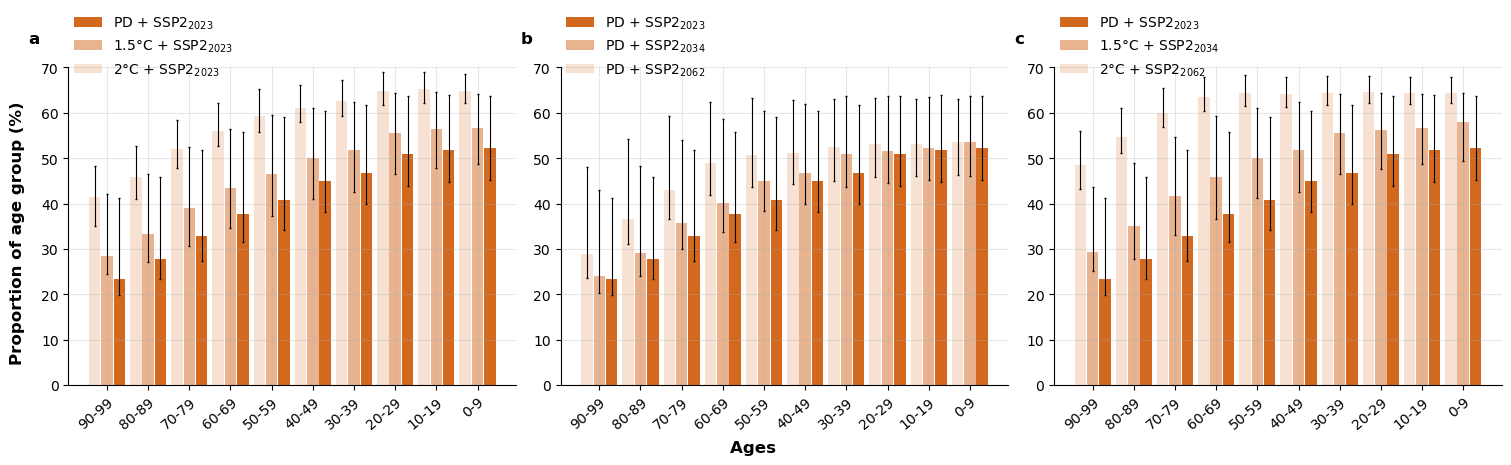

In [33]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=20


# combined effect
ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2023}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2023}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure demogrpahic effect

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# Add legend




fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14
fig.supylabel('Proportion of age group (%) ',fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0,70)
    ax.legend(frameon=False, loc=(0,.95))
    ax.set_ylabel('')
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


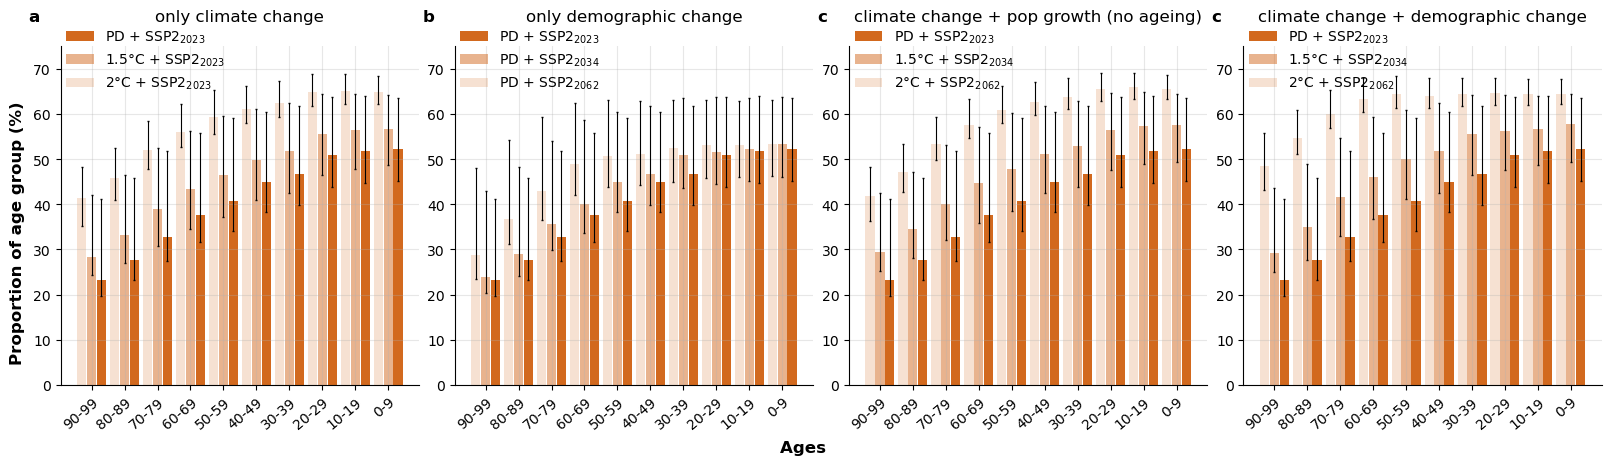

In [34]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,4,figsize=(16,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=20



# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('only climate change', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2023}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2023}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure demogrpahic effect

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('only demographic change', y=ypos)


plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# cc + pop growth (no ageing)
ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('climate change + pop growth (no ageing)', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# combined effect
ax=axes[3]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('climate change + demographic change', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)



fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14
fig.supylabel('Proportion of age group (%) ',fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0,75)
    ax.legend(frameon=False, loc=(0,.85))
    ax.set_ylabel('')
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


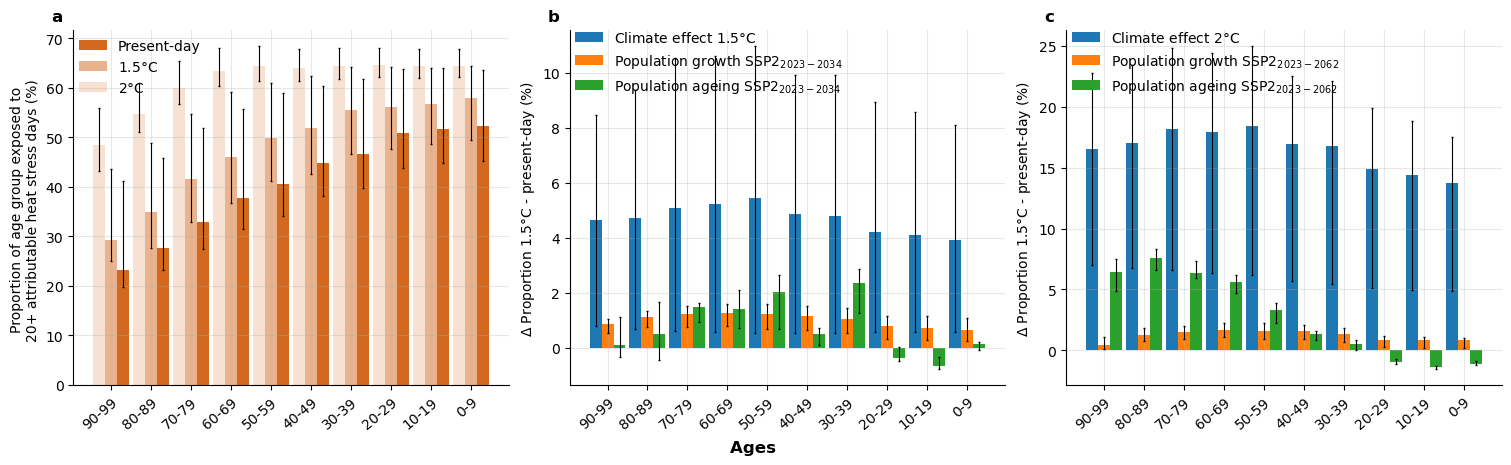

In [35]:
# settings
xpos=-.05
ypos=1


fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=20

width=.3


# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('climate change + demographic changes', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -.3,
                                              width=width
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C',
                                              alpha=.5,
                                              offset = 0,
                                              width=width
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C',
                                              alpha=.2,
                                              offset = .3,
                                              width=width
)

#ax.set_ylim(0,28)
ax.set_ylabel(f'Proportion of age group exposed to \n{n}+ attributable heat stress days (%) '); #c='0.5',size=14



# Decomposition of drivers

da_only_climate_15 = da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_only_climate_2 = da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_pop_growth_15 = da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_15

da_pop_growth_2 = da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_2

da_ageing_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_15 - da_only_climate_15

da_ageing_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_2 - da_only_climate_2


# Plot

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('decomposition of drivers present day vs. 1.5$\degree$C', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 1.5$\degree$C',
                                              offset = .3,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2034}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)


plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2034}$',
                                              offset = -.3,
                                              width=width
                                              #alpha=.5
                                              
)

#ax.set_ylim(-1,10)
ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14



ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('decomposition of drivers present day vs. 2$\degree$C', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C0',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 2$\degree$C',
                                              offset = .3,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C1',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2062}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C2',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2062}$',
                                              offset = -.3,
                                              width=width
                                              #alpha=.5
                                              
)


ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14



for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc=(0,.8))
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections_decomposition_n100.png'),bbox_inches='tight',dpi=300)


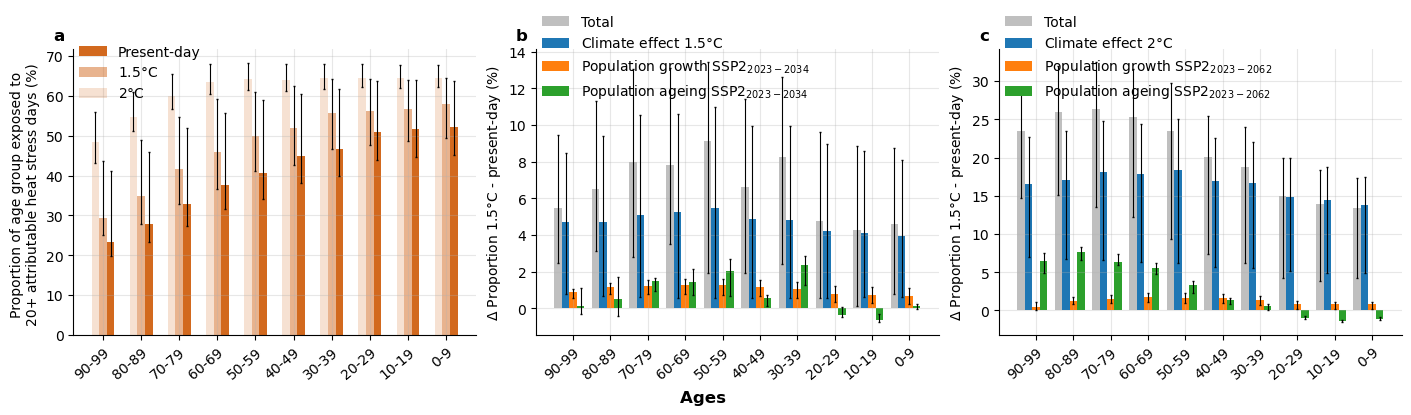

In [36]:
# settings
xpos=-.05
ypos=1


fig,axes=plt.subplots(1,3,figsize=(14,4),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=20

width=.2
offset=width

# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('climate change + demographic changes', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -offset,
                                              width=width
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C',
                                              alpha=.5,
                                              offset = 0,
                                              width=width
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C',
                                              alpha=.2,
                                              offset = offset,
                                              width=width
)

ax.set_ylabel(f'Proportion of age group exposed to \n{n}+ attributable heat stress days (%) '); #c='0.5',size=14



# Decomposition of drivers

da_only_climate_15 = da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_only_climate_2 = da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_pop_growth_15 = da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_15

da_pop_growth_2 = da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_2

da_ageing_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_15 - da_only_climate_15

da_ageing_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_2 - da_only_climate_2

da_total_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_total_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

# Plot

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 1.5$\degree$C',
                                              offset = offset,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2034}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)


plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2034}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)



#ax.set_ylim(-1,10)
ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14



ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C0',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 2$\degree$C',
                                              offset = offset,
                                              width=width
                                              #
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C1',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2062}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C2',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2062}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)


ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14



for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc=(0,.8))
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections_decomposition_n100.png'),bbox_inches='tight',dpi=300)


## 1+ days

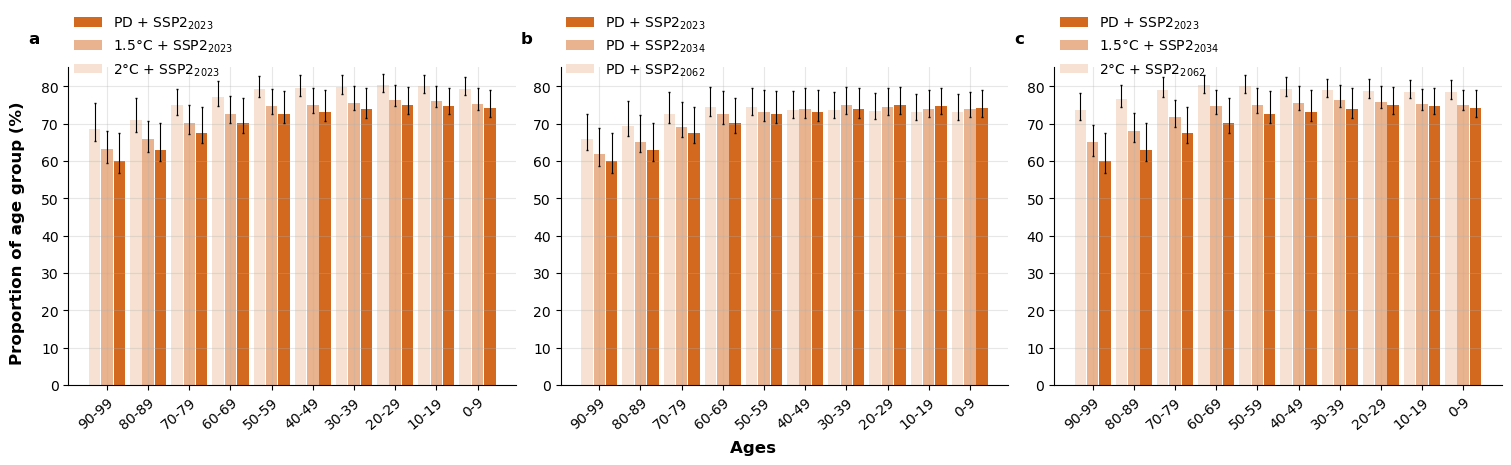

In [37]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=1


# combined effect
ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2023}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2023}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure demogrpahic effect

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# Add legend




fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14
fig.supylabel('Proportion of age group (%) ',fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0,85)
    ax.legend(frameon=False, loc=(0,.95))
    ax.set_ylabel('')
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


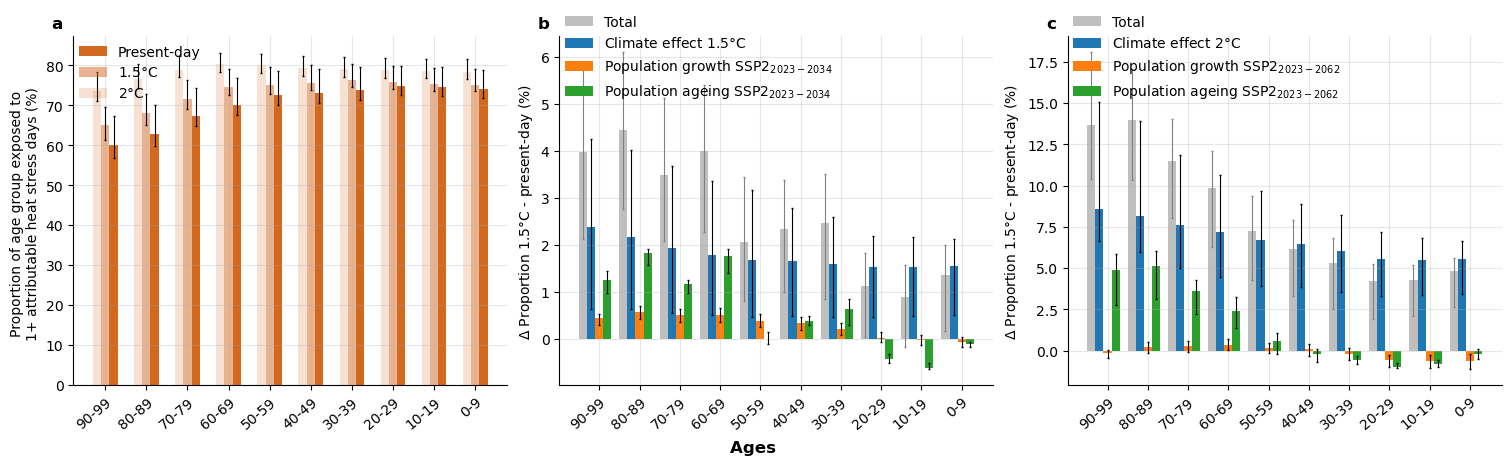

In [38]:
# settings
xpos=-.05
ypos=1


fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=1

width=.2
offset=width

# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('climate change + demographic changes', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -offset,
                                              width=width
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C',
                                              alpha=.5,
                                              offset = 0,
                                              width=width
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C',
                                              alpha=.2,
                                              offset = offset,
                                              width=width
)

ax.set_ylabel(f'Proportion of age group exposed to \n{n}+ attributable heat stress days (%) '); #c='0.5',size=14



# Decomposition of drivers

da_only_climate_15 = da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_only_climate_2 = da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_pop_growth_15 = da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_15

da_pop_growth_2 = da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_2

da_ageing_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_15 - da_only_climate_15

da_ageing_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_2 - da_only_climate_2

da_total_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_total_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

# Plot

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='gray',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 1.5$\degree$C',
                                              offset = offset,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2034}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)


plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2034}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)



#ax.set_ylim(-1,10)
ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14



ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='gray',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C0',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 2$\degree$C',
                                              offset = offset,
                                              width=width
                                              #
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C1',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2062}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C2',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2062}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)


ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14



for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc=(0,.8))
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections_decomposition_n100.png'),bbox_inches='tight',dpi=300)


## 100+ days

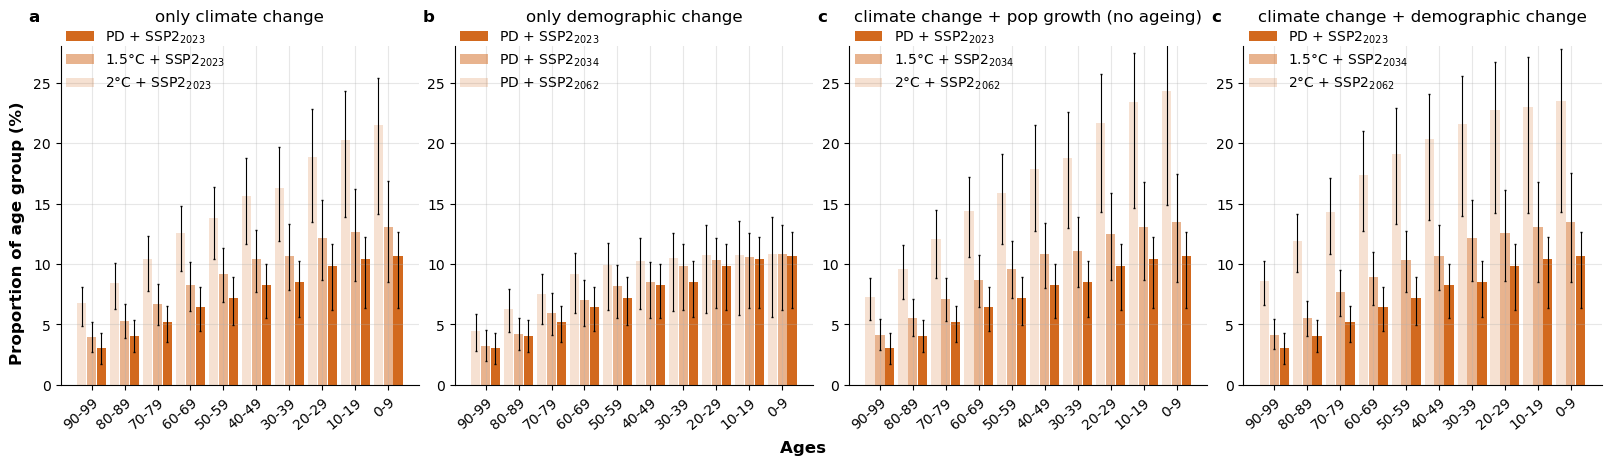

In [39]:
# settings
xpos=-.09
ypos=1.05


fig,axes=plt.subplots(1,4,figsize=(16,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=100



# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('only climate change', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2023}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2023}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)


# pure demogrpahic effect

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('only demographic change', y=ypos)


plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_fc.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# cc + pop growth (no ageing)
ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('climate change + pop growth (no ageing)', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)

# combined effect
ax=axes[3]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
ax.set_title('climate change + demographic change', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='PD + SSP2$_{2023}$',
                                              offset = -.3,
                                              width=.28
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C + SSP2$_{2034}$',
                                              alpha=.5,
                                              offset = 0,
                                              width=.28
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C + SSP2$_{2062}$',
                                              alpha=.2,
                                              offset = .3,
                                              width=.28
)



fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14
fig.supylabel('Proportion of age group (%) ',fontweight='bold'); #c='0.5',size=14


for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0,28)
    ax.legend(frameon=False, loc=(0,.85))
    ax.set_ylabel('')
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


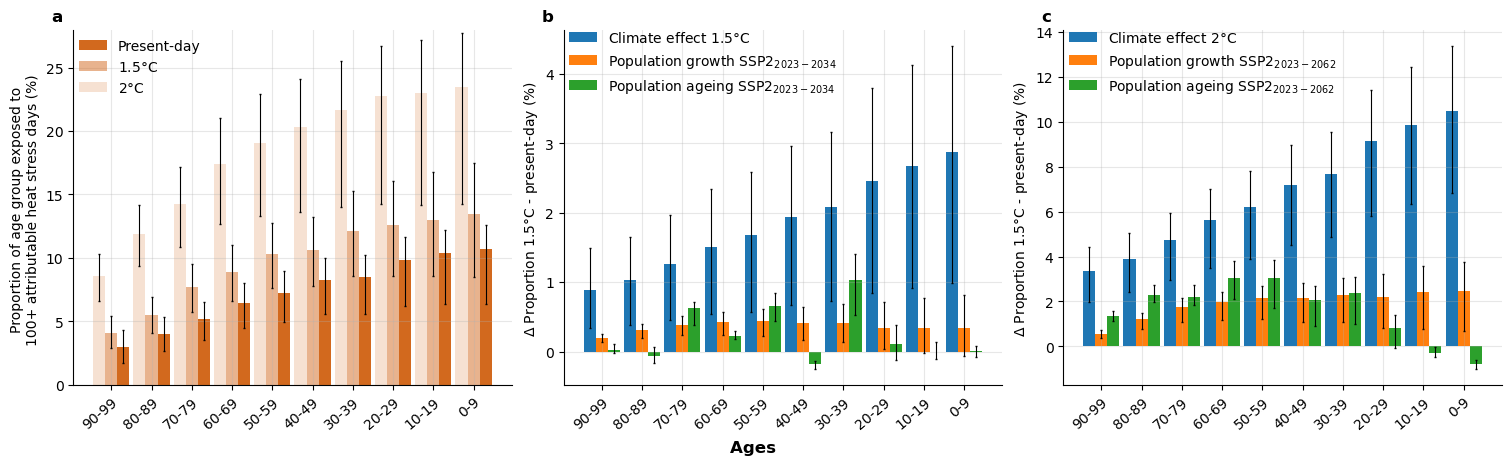

In [40]:
# settings
xpos=-.05
ypos=1


fig,axes=plt.subplots(1,3,figsize=(15,4.5),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=100

width=.3


# pure climate effect
ax=axes[0]
ax.set_title('a',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('climate change + demographic changes', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = -.3,
                                              width=width
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C',
                                              alpha=.5,
                                              offset = 0,
                                              width=width
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C',
                                              alpha=.2,
                                              offset = .3,
                                              width=width
)

ax.set_ylim(0,28)
ax.set_ylabel('Proportion of age group exposed to \n100+ attributable heat stress days (%) '); #c='0.5',size=14



# Decomposition of drivers

da_only_climate_15 = da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_only_climate_2 = da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_pop_growth_15 = da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_15

da_pop_growth_2 = da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_2

da_ageing_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_15 - da_only_climate_15

da_ageing_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_2 - da_only_climate_2


# Plot

ax=axes[1]
ax.set_title('b',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('decomposition of drivers present day vs. 1.5$\degree$C', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 1.5$\degree$C',
                                              offset = .3,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2034}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)


plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2034}$',
                                              offset = -.3,
                                              width=width
                                              #alpha=.5
                                              
)

#ax.set_ylim(-1,10)
ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14



ax=axes[2]
ax.set_title('c',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('decomposition of drivers present day vs. 2$\degree$C', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C0',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 2$\degree$C',
                                              offset = .3,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C1',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2062}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C2',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2062}$',
                                              offset = -.3,
                                              width=width
                                              #alpha=.5
                                              
)


ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14



for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc=(0,.8))
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections_decomposition_n100.png'),bbox_inches='tight',dpi=300)


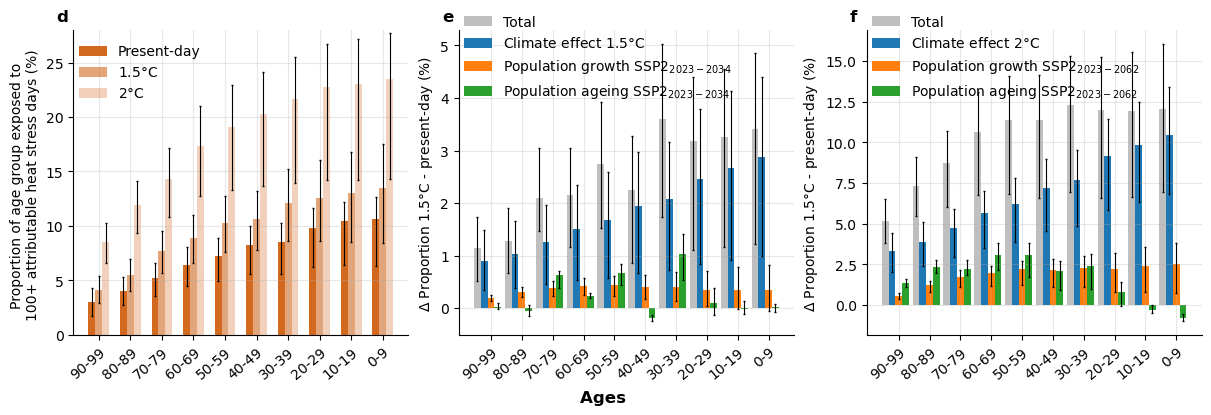

In [ ]:
# settings
xpos=-.05
ypos=1


fig,axes=plt.subplots(1,3,figsize=(12,4),layout='constrained',facecolor='none') # 10,5

axes=axes.flatten()

n=100

width=.22
offset=width
errcolor='gray'

# pure climate effect
ax=axes[0]
ax.set_title('d',loc='left',fontweight='bold',x=xpos,y=ypos)
#ax.set_title('climate change + demographic changes', y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Present-day',
                                              offset = offset,
                                              width=width
                                              
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='1.5$\degree$C',
                                              alpha=.6,
                                              offset = 0,
                                              width=width
)
plot_barplot_n_prop_people_atleastx_modelmedian(da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='2$\degree$C',
                                              alpha=.3,
                                              offset = -offset,
                                              width=width
)

ax.set_ylim(0,28)
ax.set_ylabel('Proportion of age group exposed to \n100+ attributable heat stress days (%) '); #c='0.5',size=14



# Decomposition of drivers

da_only_climate_15 = da_prop_people_ndays_models_15_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_only_climate_2 = da_prop_people_ndays_models_2_fd.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_pop_growth_15 = da_prop_people_ndays_models_15_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_15

da_pop_growth_2 = da_prop_people_ndays_models_2_cas.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_only_climate_2

da_ageing_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_15 - da_only_climate_15

da_ageing_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') - da_pop_growth_2 - da_only_climate_2

da_total_15 = da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

da_total_2 = da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') - da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}')

# Plot

ax=axes[1]
ax.set_title('e',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 1.5$\degree$C',
                                              offset = offset,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2034}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)


plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_15 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              #color='chocolate',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2034}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)



#ax.set_ylim(-1,10)
ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14



ax=axes[2]
ax.set_title('f',loc='left',fontweight='bold',x=xpos,y=ypos)

plot_barplot_n_prop_people_atleastx_modelmedian(da_total_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='gray',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Total',
                                              offset = offset*2,
                                              width=width,
                                              alpha=.5
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_only_climate_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C0',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Climate effect 2$\degree$C',
                                              offset = offset,
                                              width=width
                                              #
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_pop_growth_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C1',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population growth SSP2$_{2023-2062}$',
                                              offset = 0,
                                              width=width
                                              #alpha=.5
                                              
)

plot_barplot_n_prop_people_atleastx_modelmedian(da_ageing_2 * 100, 
                                              unit=1,  
                                              ax=ax, 
                                              proportion=True, 
                                              legend=True,
                                              errcolor='k',
                                              color='C2',
                                              set_xticklabel=True,
                                              ylabel='Proportion of age group (%)',
                                              label='Population ageing SSP2$_{2023-2062}$',
                                              offset = -offset,
                                              width=width
                                              #alpha=.5
                                              
)


ax.set_ylabel('$\Delta$ Proportion 1.5$\degree$C - present-day (%) '); #c='0.5',size=14


fig.supxlabel('Ages ', y=0,fontweight='bold'); #c='0.5',size=14



for ax in axes:
    ax.invert_xaxis()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc=(0,.75))
    ax.grid(alpha=.3)




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_demographic_climate_effect_projections_decomposition_n100.png'),bbox_inches='tight',dpi=300)


In [42]:
n = 100

df = (da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

df.median(axis=1)

age_ranges
0     10.668549
10    10.420601
20     9.855027
30     8.524942
40     8.239828
50     7.226472
60     6.438742
70     5.196971
80     4.013171
90     3.013086
dtype: object

In [ ]:
n = 100

df = (da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

df.median(axis=1)

age_ranges
0     13.465932
10    13.023052
20    12.594531
30    12.121486
40    10.634529
50    10.311958
60     8.901217
70     7.676203
80     5.505522
90     4.112484
dtype: object

In [ ]:
n = 100

df = (da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

df.median(axis=1)

age_ranges
0     23.470916
10    23.024042
20    22.721263
30    21.621702
40    20.308156
50    19.061331
60    17.380625
70    14.272852
80    11.886581
90     8.559886
dtype: object

In [ ]:
n = 100

df = (da_prop_people_ndays_models.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

(df.loc[0] / df.loc[60]).median()

1.5016250190055946

In [ ]:
n = 100

df = (da_prop_people_ndays_models_15.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

(df.loc[0] / df.loc[60]).median()

1.4798730782558924

In [ ]:
n = 100

df = (da_prop_people_ndays_models_2.sel(features=f'prop_atleast_{n}') * 100).to_pandas().T

(df.loc[0] / df.loc[60]).median()

1.3188384033697502

## Maps

In [57]:
year=2023
da_nAHD_pd = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, year_pres=year) 

temp_target=1.5
da_nAHD_15 = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=temp_target) # see here i coded what models it is in the fxn 

temp_target=2
da_nAHD_2 = open_all_nAHD(GCMs,  metric='WBGT28', outdirname=dirname, temp_target=temp_target) # see here i coded what models it is in the fxn 


In [58]:
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import matplotlib.gridspec as gridspec

def plot_map_nAHD(data_plot,
                    ax,
                    proj=ccrs.PlateCarree(),
                    vmin = -100,
                    vmax = 200, 
                    levels = 11,
                    title_label = None,
                  title=True, 
                  skew=True,
                  cmap = 'RdBu_r',
                  extend='both'
                  
            ):

    if isinstance(levels, int):
        levels = np.linspace(vmin, vmax, levels)

    if skew:
        cmap = LinearSegmentedColormap.from_list('new_RdBu_r', plt.get_cmap('RdBu_r')(np.linspace(0.25, 1, 192))) 
        norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
    else:
        cmap = cmap
    crs = ccrs.PlateCarree()
    ax.set_extent([-179.75, 179.75, -60, 90], crs=ccrs.PlateCarree())

    # plot
    plot = data_plot.plot(vmin=vmin, vmax=vmax, cmap=cmap, transform=crs, levels=levels, extend=extend, add_colorbar=False, ax=ax)
    ax.coastlines(color='black', linewidth=0.8)
    if title:
        try: 
            ax.set_title(f'{data_plot.dataset.values} \n{round(data_plot.min().values, 0)}, {round(data_plot.max().values,0)}, {round(data_plot.mean().values,0)}')
        except:
            ax.set_title(f'{data_plot.model.values} \n{data_plot.min().values.round(0)}, {data_plot.max().values.round(0)}, {data_plot.mean().values.round(0)}')
    else:
        ax.set_title('')
            
    ax.set_title(title_label, loc='left',fontweight='bold')

    return plot 

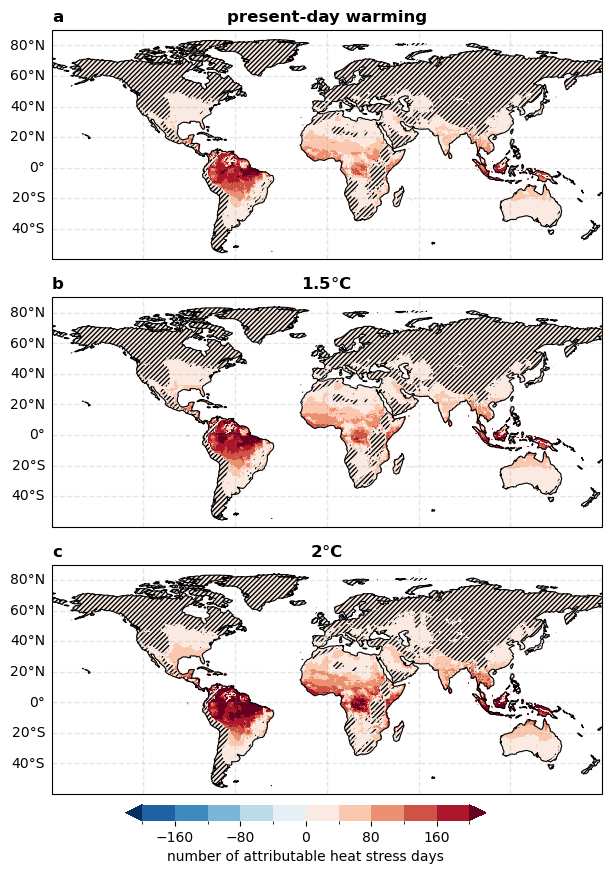

In [ ]:
# plot MMM 

landmask = get_mask()

# Settings
proj = crs = ccrs.PlateCarree()
vmax=200
vmin=-vmax
levels = np.linspace(vmin, vmax, 11) # standard in fxn 

fig, axes = plt.subplots(3,1, figsize=(6,8),layout='constrained',subplot_kw={'projection': crs})

axes=axes.flatten()

for ax, data, tit1,tit2 in zip(axes, [da_nAHD_pd, da_nAHD_15,da_nAHD_2], ['a', 'b', 'c' ],
                            ['present-day warming', '1.5$\degree$C', '2$\degree$C' ]):

    data_plot = data.mean(dim='model') * landmask

    plot = plot_map_nAHD(data_plot,
                ax, vmin=vmin, vmax=vmax, levels=levels, skew=False, title=False
                    )

    # stippling - delete this to have without significance assessment
    sig = np.abs(data_plot) > 1
    # hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])

    # ar6_land = regionmask.defined_regions.ar6.land
    # ar6_plot = ar6_land.plot(label="abbrev")

    # # Loop over all text objects in the axes
    # for txt in ar6_plot.texts:
    #     if txt.get_bbox_patch() is not None:
    #         txt.get_bbox_patch().set_alpha(0.3)  # 0 = fully transparent, 1 = opaque


    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=1, color='gray', alpha=0.2, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    ax.set_title(tit1, fontweight='bold', loc='left');
    ax.set_title(tit2, loc='center',fontweight='bold')


# Colorbar
cax = fig.add_axes([0.2, -.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('number of attributable heat stress days' )
cbar.outline.set_edgecolor('none')




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


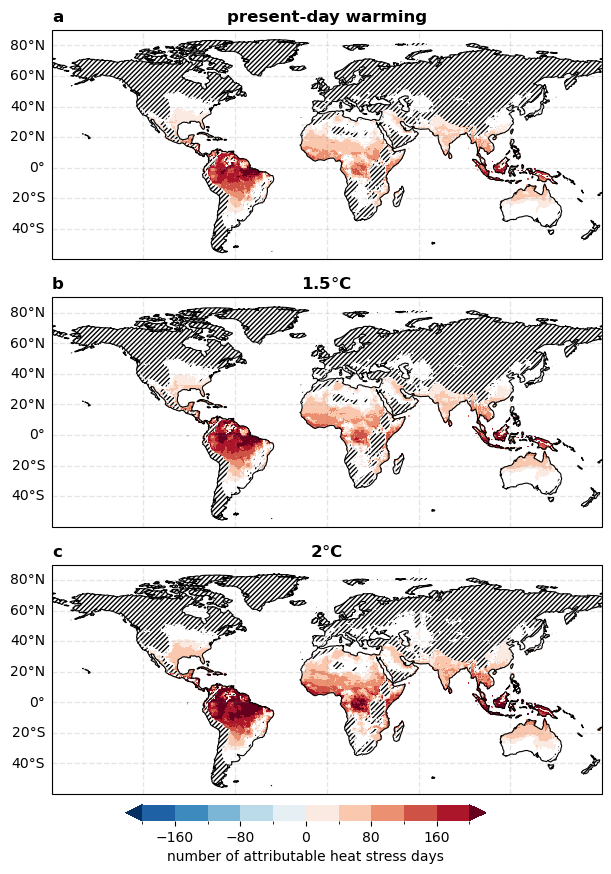

In [ ]:
# plot MMM 

landmask = get_mask()

# Settings
proj = crs = ccrs.PlateCarree()
vmax=200
vmin=-vmax
levels = np.linspace(vmin, vmax, 11) # standard in fxn 

fig, axes = plt.subplots(3,1, figsize=(6,8),layout='constrained',subplot_kw={'projection': crs})

axes=axes.flatten()

for ax, data, tit1,tit2 in zip(axes, [da_nAHD_pd, da_nAHD_15,da_nAHD_2], ['a', 'b', 'c' ],
                            ['present-day warming', '1.5$\degree$C', '2$\degree$C' ]):

    data_plot = data.mean(dim='model') * landmask

    plot = plot_map_nAHD(data_plot.where(data_plot>=20),
                ax, vmin=vmin, vmax=vmax, levels=levels, skew=False, title=False
                    )

    # stippling - delete this to have without significance assessment
    sig = np.abs(data_plot) > 1
    # hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])

    # ar6_land = regionmask.defined_regions.ar6.land
    # ar6_plot = ar6_land.plot(label="abbrev")

    # # Loop over all text objects in the axes
    # for txt in ar6_plot.texts:
    #     if txt.get_bbox_patch() is not None:
    #         txt.get_bbox_patch().set_alpha(0.3)  # 0 = fully transparent, 1 = opaque


    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=1, color='gray', alpha=0.2, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    ax.set_title(tit1, fontweight='bold', loc='left');
    ax.set_title(tit2, loc='center',fontweight='bold')


# Colorbar
cax = fig.add_axes([0.2, -.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('number of attributable heat stress days' )
cbar.outline.set_edgecolor('none')




# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_climate_effect_projections.png'),bbox_inches='tight',dpi=300)


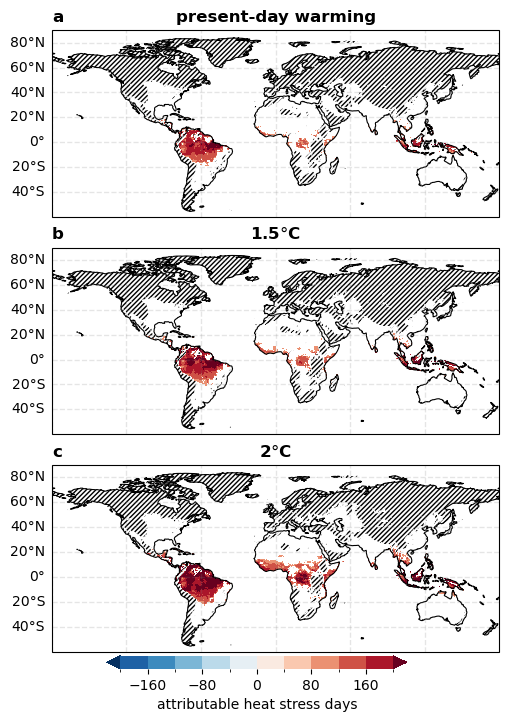

: 

In [ ]:
# plot MMM 

landmask = get_mask()

# Settings
proj = crs = ccrs.PlateCarree()
vmax=200
vmin=-vmax
levels = np.linspace(vmin, vmax, 11) # standard in fxn 

fig, axes = plt.subplots(3,1, figsize=(5,6.5),layout='constrained',subplot_kw={'projection': crs})

axes=axes.flatten()

for ax, data, tit1,tit2 in zip(axes, [da_nAHD_pd, da_nAHD_15,da_nAHD_2], ['a', 'b', 'c' ],
                            ['present-day warming', '1.5$\degree$C', '2$\degree$C' ]):

    data_plot = data.mean(dim='model') * landmask

    plot = plot_map_nAHD(data_plot.where(data_plot>=100),
                ax, vmin=vmin, vmax=vmax, levels=levels, skew=False, title=False
                    )

    # stippling - delete this to have without significance assessment
    sig = np.abs(data_plot) > 1
    # hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])

    # ar6_land = regionmask.defined_regions.ar6.land
    # ar6_plot = ar6_land.plot(label="abbrev")

    # # Loop over all text objects in the axes
    # for txt in ar6_plot.texts:
    #     if txt.get_bbox_patch() is not None:
    #         txt.get_bbox_patch().set_alpha(0.3)  # 0 = fully transparent, 1 = opaque


    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=1, color='gray', alpha=0.2, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    ax.set_title(tit1, fontweight='bold', loc='left');
    ax.set_title(tit2, loc='center',fontweight='bold')


# Colorbar
cax = fig.add_axes([0.2, -.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('attributable heat stress days' )
cbar.outline.set_edgecolor('none')

# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_climate_effect_projections_100days.png'),bbox_inches='tight',dpi=300)


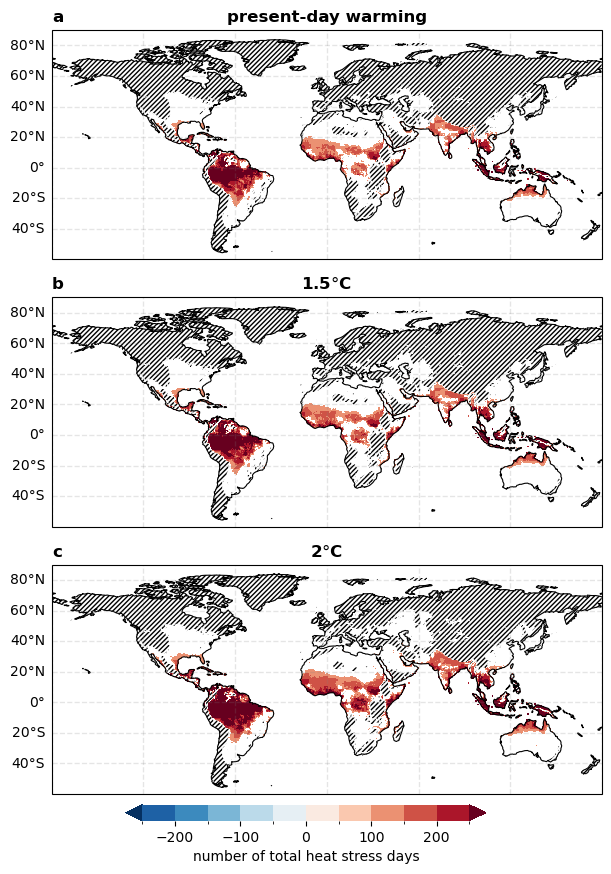

In [ ]:
# plot MMM 


# total heat stress days

landmask = get_mask()

# Settings
proj = crs = ccrs.PlateCarree()
vmax=250
vmin=-vmax
levels = np.linspace(vmin, vmax, 11) # standard in fxn 

fig, axes = plt.subplots(3,1, figsize=(6,8),layout='constrained',subplot_kw={'projection': crs})

axes=axes.flatten()

for ax, data, tit1,tit2 in zip(axes, [da_p1_models, da_p1_models_15,da_p1_models_2], ['a', 'b', 'c' ],
                            ['present-day warming', '1.5$\degree$C', '2$\degree$C' ]):

    data_plot = data.mean(dim='model') * landmask * 365

    plot = plot_map_nAHD(data_plot.where(data_plot>=100),
                ax, vmin=vmin, vmax=vmax, levels=levels, skew=False, title=False
                    )

    # stippling - delete this to have without significance assessment
    sig = np.abs(data_plot) > 1
    # hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=1, color='gray', alpha=0.2, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    ax.set_title(tit1, fontweight='bold', loc='left');
    ax.set_title(tit2, loc='center',fontweight='bold')


# Colorbar
cax = fig.add_axes([0.2, -.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('number of total heat stress days' )
cbar.outline.set_edgecolor('none')

# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_climate_effect_projections_100days.png'),bbox_inches='tight',dpi=300)


In [ ]:
# plot MMM 


# total heat stress days

landmask = get_mask()

# Settings
proj = crs = ccrs.PlateCarree()
vmax=350
vmin=-vmax
levels = np.linspace(vmin, vmax, 11) # standard in fxn 

fig, axes = plt.subplots(3,1, figsize=(6,8),layout='constrained',subplot_kw={'projection': crs})

axes=axes.flatten()

for ax, data, tit1,tit2 in zip(axes, [da_p1_models, da_p1_models_15,da_p1_models_2], ['a', 'b', 'c' ],
                            ['present-day warming', '1.5$\degree$C', '2$\degree$C' ]):

    data_plot = data.mean(dim='model') * landmask * 365

    plot = plot_map_nAHD(data_plot,
                ax, vmin=vmin, vmax=vmax, levels=levels, skew=False, title=False
                    )

    # stippling - delete this to have without significance assessment
    sig = np.abs(data_plot) > 1
    # hatch = n.s.
    sig_inv = ~sig
    cont = ax.contourf(sig.lon, sig.lat, sig_inv.where(landmask==1,False).values, hatches=['', '///////'],  colors=['none'])

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                    linewidth=1, color='gray', alpha=0.2, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False

    ax.set_title(tit1, fontweight='bold', loc='left');
    ax.set_title(tit2, loc='center',fontweight='bold')


# Colorbar
cax = fig.add_axes([0.2, -.02, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(plot, cax=cax, orientation='horizontal')
cbar.set_label('number of total heat stress days' )
cbar.outline.set_edgecolor('none')

# savefigs=True
# if savefigs:
#     plt.savefig(os.path.join(figdir,'figSI_climate_effect_projections_100days.png'),bbox_inches='tight',dpi=300)


NameError: name 'get_mask' is not defined